# Artifact Rejection

## 1. Introduction to EEG Signals
---
### What is EEG?
EEG signals are inherently **non-stationary**, meaning their statistical properties (like mean and variance) change over time. 

> **Definition:** Electroencephalography is the measurement, amplification, and registration of fluctuating electrical fields produced by the brain as a function of time.

#### The Spatio-Temporal Trade-off
EEG is characterized by its **high temporal resolution** (capturing changes in milliseconds) but lacks **spatial resolution** (difficulty pinpointing the exact cortical source of a signal).

#### EEG Artifacts

The primary challenge in EEG analysis is the presence of **artifacts** — signals not originating from the brain. They are broadly classified by origin:

##### 2.1 Physiological Artifacts
These are non-EEG signals generated by the human body.

*   **Eye Blinks:** The cornea is positively charged relative to the retina. During a blink, eyelid movement and eyeball rotation invert this polarity, creating a positive current toward the scalp. Blink artifacts concentrate in the **delta and theta** bands.

![eyeblink](images/Eyeblinkartifact.png)


*   **Eye Movements (Saccades):** Lateral eye movements generate current toward the sides of the head, producing box-shaped deflections with opposite polarity on each side. Most prominent near the temples but affect distant channels too. Spectral content peaks in delta/theta but extends up to **~20 Hz**.

![eyemovement](images/Lateraleyemovement.png)

*   **Muscle Artifacts (EMG):** Muscular activation produces high-frequency noise overlapping the **entire EEG spectrum**. Teeth clenching generates large scalp-wide noise; subtler artifacts arise from jaw and forehead muscles.


![muscelmovement](images/musclemovement.png)

*   **Pulse Artifact:** Heartbeat-driven pulsation of head arteries causes slight rhythmic electrode movement.

*   **Sweating / Skin Potentials:** Even mild sweating changes skin conductivity, producing slow voltage drifts concentrated in **low frequencies**.

*   **Body Movement:** Physical movement displaces the EEG cap over the scalp, especially when the cap is loose.
![bodymovement](images/Bodymovement.png)
##### 2.2 Technical Artifacts
These originate from equipment or the environment.

*   **Line Noise (Electromagnetic Interference):** Alternating current in the room's wiring generates electromagnetic noise picked up by EEG cables at **50 Hz** (e.g., Europe) or **60 Hz** (e.g., North America), depending on the local power grid.


![linenoise](images/Linenoiseartifact.png)

![Biological Artifacts](images/EEG_BIOLOGICAL_artifacts.png)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# --- Build a long synthetic EEG with labeled artifacts ---
np.random.seed(42)
fs = 256
duration = 20  # seconds
t = np.linspace(0, duration, fs * duration)

# Clean EEG: alpha (10 Hz) + theta (6 Hz) + beta (20 Hz)
clean = (0.8 * np.sin(2 * np.pi * 10 * t)
         + 0.3 * np.sin(2 * np.pi * 6 * t)
         + 0.2 * np.sin(2 * np.pi * 20 * t)
         + 0.15 * np.random.randn(len(t)))

# Define artifacts: (start_sec, end_sec, label, generator)
artifacts = [
    (2.0, 2.15, "Eye Blink",
     lambda t0: 5 * np.exp(-((t - t0) ** 2) / (2 * 0.03 ** 2))),
    (5.0, 5.15, "Eye Blink",
     lambda t0: 4.5 * np.exp(-((t - t0) ** 2) / (2 * 0.03 ** 2))),
    (7.5, 8.5, "Muscle (EMG)",
     lambda _: np.where((t > 7.5) & (t < 8.5),
                         1.8 * np.random.RandomState(1).randn(len(t)), 0)),
    (10.5, 11.5, "Eye Movement",
     lambda _: np.where((t > 10.5) & (t < 11.5),
                         2.5 * np.sign(np.sin(2 * np.pi * 1.5 * t)), 0)),
    (13.0, 16.0, "Slow Drift (Sweat)",
     lambda _: np.where((t > 13.0) & (t < 16.0),
                         2.0 * np.sin(2 * np.pi * 0.3 * (t - 13)), 0)),
    (17.0, 18.5, "Line Noise (50 Hz)",
     lambda _: np.where((t > 17.0) & (t < 18.5),
                         1.0 * np.sin(2 * np.pi * 50 * t), 0)),
]

# Inject artifacts into the signal
signal = clean.copy()
artifact_regions = []
for start, end, label, gen in artifacts:
    mid = (start + end) / 2
    signal += gen(mid)
    artifact_regions.append((start, end, label))

# --- Animate a scrolling window ---
win_sec = 4
scroll_speed = 0.05

fig, ax = plt.subplots(figsize=(12, 4))
plt.close(fig)

line, = ax.plot([], [], color="steelblue", linewidth=0.8)
ax.set_ylim(np.min(signal) - 1, np.max(signal) + 2.5)
ax.set_ylabel("Amplitude (μV)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_title("EEG Recording — Artifact Identification", fontsize=13)

active_patches = []
active_texts = []

def init():
    line.set_data([], [])
    return [line]

def update(frame):
    for p in active_patches:
        p.remove()
    for txt in active_texts:
        txt.remove()
    active_patches.clear()
    active_texts.clear()

    t_start = frame * scroll_speed
    t_end = t_start + win_sec
    mask = (t >= t_start) & (t <= t_end)

    line.set_data(t[mask], signal[mask])
    ax.set_xlim(t_start, t_end)

    for a_start, a_end, label in artifact_regions:
        if a_end >= t_start and a_start <= t_end:
            vis_start = max(a_start, t_start)
            vis_end = min(a_end, t_end)
            rect = Rectangle((vis_start, ax.get_ylim()[0] + 0.2),
                              vis_end - vis_start,
                              ax.get_ylim()[1] - ax.get_ylim()[0] - 0.4,
                              linewidth=2, edgecolor="red",
                              facecolor="red", alpha=0.12)
            ax.add_patch(rect)
            active_patches.append(rect)
            txt = ax.text((vis_start + vis_end) / 2,
                          ax.get_ylim()[1] - 0.6,
                          label, ha="center", va="top",
                          fontsize=10, fontweight="bold", color="red",
                          bbox=dict(boxstyle="round,pad=0.2",
                                    fc="white", ec="red", alpha=0.85))
            active_texts.append(txt)

    return [line] + active_patches + active_texts

n_frames = int((duration - win_sec) / scroll_speed)
anim = FuncAnimation(fig, update, init_func=init,
                     frames=n_frames, interval=60, blit=False)

HTML(anim.to_jshtml())


Animation size has reached 20977760 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


# 3. Artifact Rejection: Regression & Filtering
---

### Basic Filtering Techniques
The most common first-line approaches for artifact rejection:

*   **High-pass filter:** Attenuates frequencies below a low-cutoff (e.g., removes slow drifts).
*   **Low-pass filter:** Reduces frequencies above a high-cutoff (e.g., removes high-frequency muscle noise).
*   **Notch filter:** A band-rejection filter that attenuates line noise at **50 or 60 Hz**.

These are standard preprocessing steps applied to nearly all EEG recordings.

> **Caution:** Most EEG data is recorded with 32 or 64 channel electrodes. Many artifact rejection methods (e.g., ICA, interpolation) are designed for multi-channel setups. For our own dataset, we must consider **single-channel artifact rejection**, which limits the available techniques and requires careful adaptation.

### Regression-based Methods
Traditionally, regression and linear filtering-based analyses are employed to reject artifactual noises from corrupted signals.

*   **Mechanism:** These methods rely on extra regressive channels (like an EOG channel) to "subtract" noise.
*   **Weakness:** A fundamental weakness is that the **spectral range** of some artifacts overlaps with the spectral range of the actual EEG signal, potentially leading to the loss of real neural data.

# 4. The Wavelet Transform (WT)
---
Transforming a time-domain signal into the **time-frequency domain** offers major advantages in extracting multiple components of a signal.

The wavelet transform decomposes a time-domain signal into its **wavelet coefficients** through a **mother wavelet function**. These coefficients are obtained by performing shifting and dilation of the mother wavelet:

$$ \Psi_{a,b}(t) = \Psi \left( \frac{t-b}{a} \right) $$

Where:
*   **$a$**: The scaling parameter.
*   **$b$**: The shifting parameter.

#### Types of Wavelet Transform
1.  **Discrete Wavelet Transform (DWT)**
2.  **Continuous Wavelet Transform (CWT)**
3.  **Stationary Wavelet Transform (SWT)**

The coefficients are modified by taking advantage of their local properties, and the transformation is then inverted to obtain a clean version of the signal.

> **Intuition - The Choice of Wavelet:** 
> Choice of wavelet matters. Imagine zooming in and out of a signal with differently stretched oscillatory lenses. You want to pick a "lens" (mother wavelet) that most closely mirrors the shape of the feature (e.g., a blink or a spike) you are trying to isolate.

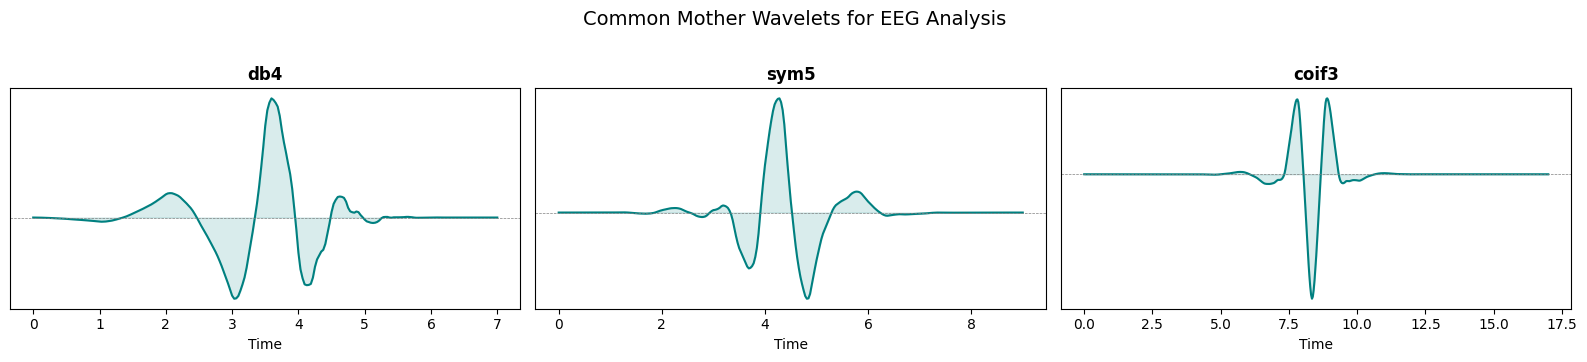

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- Visualise common mother wavelets used in EEG ---
wavelet_names = ["db4", "sym5", "coif3"]
fig, axes = plt.subplots(1, len(wavelet_names), figsize=(16, 3.5))

for ax, name in zip(axes, wavelet_names):
    try:
        wav = pywt.ContinuousWavelet(name)
        # For continuous wavelets use pywt's wavefun
        [psi, x] = wav.wavefun(precision=10)
    except Exception:
        wav = pywt.Wavelet(name)
        [phi, psi, x] = wav.wavefun(level=5)[:3]
    
    ax.plot(x, psi, color="teal", linewidth=1.5)
    ax.fill_between(x, psi, alpha=0.15, color="teal")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Time")
    ax.set_yticks([])

fig.suptitle("Common Mother Wavelets for EEG Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

![Wavelettransform](images/Artifact_wavelet.png)

![Wavelet](images/Waveletthresholdingwithgraphs.png)

Method                     Pearson r       RMSE
───────────────────────────────────────────────
Fixed Universal               0.6208     0.5976
Per-Level Adaptive            0.0135     0.8237
Level-Dep Scaling (α)         0.0151     0.8335
BayesShrink                   0.7345     0.5784
NeighBlock                    0.6389     0.5868
Time-Adaptive                 0.0133     0.8195
SURE                          0.5371     0.6248


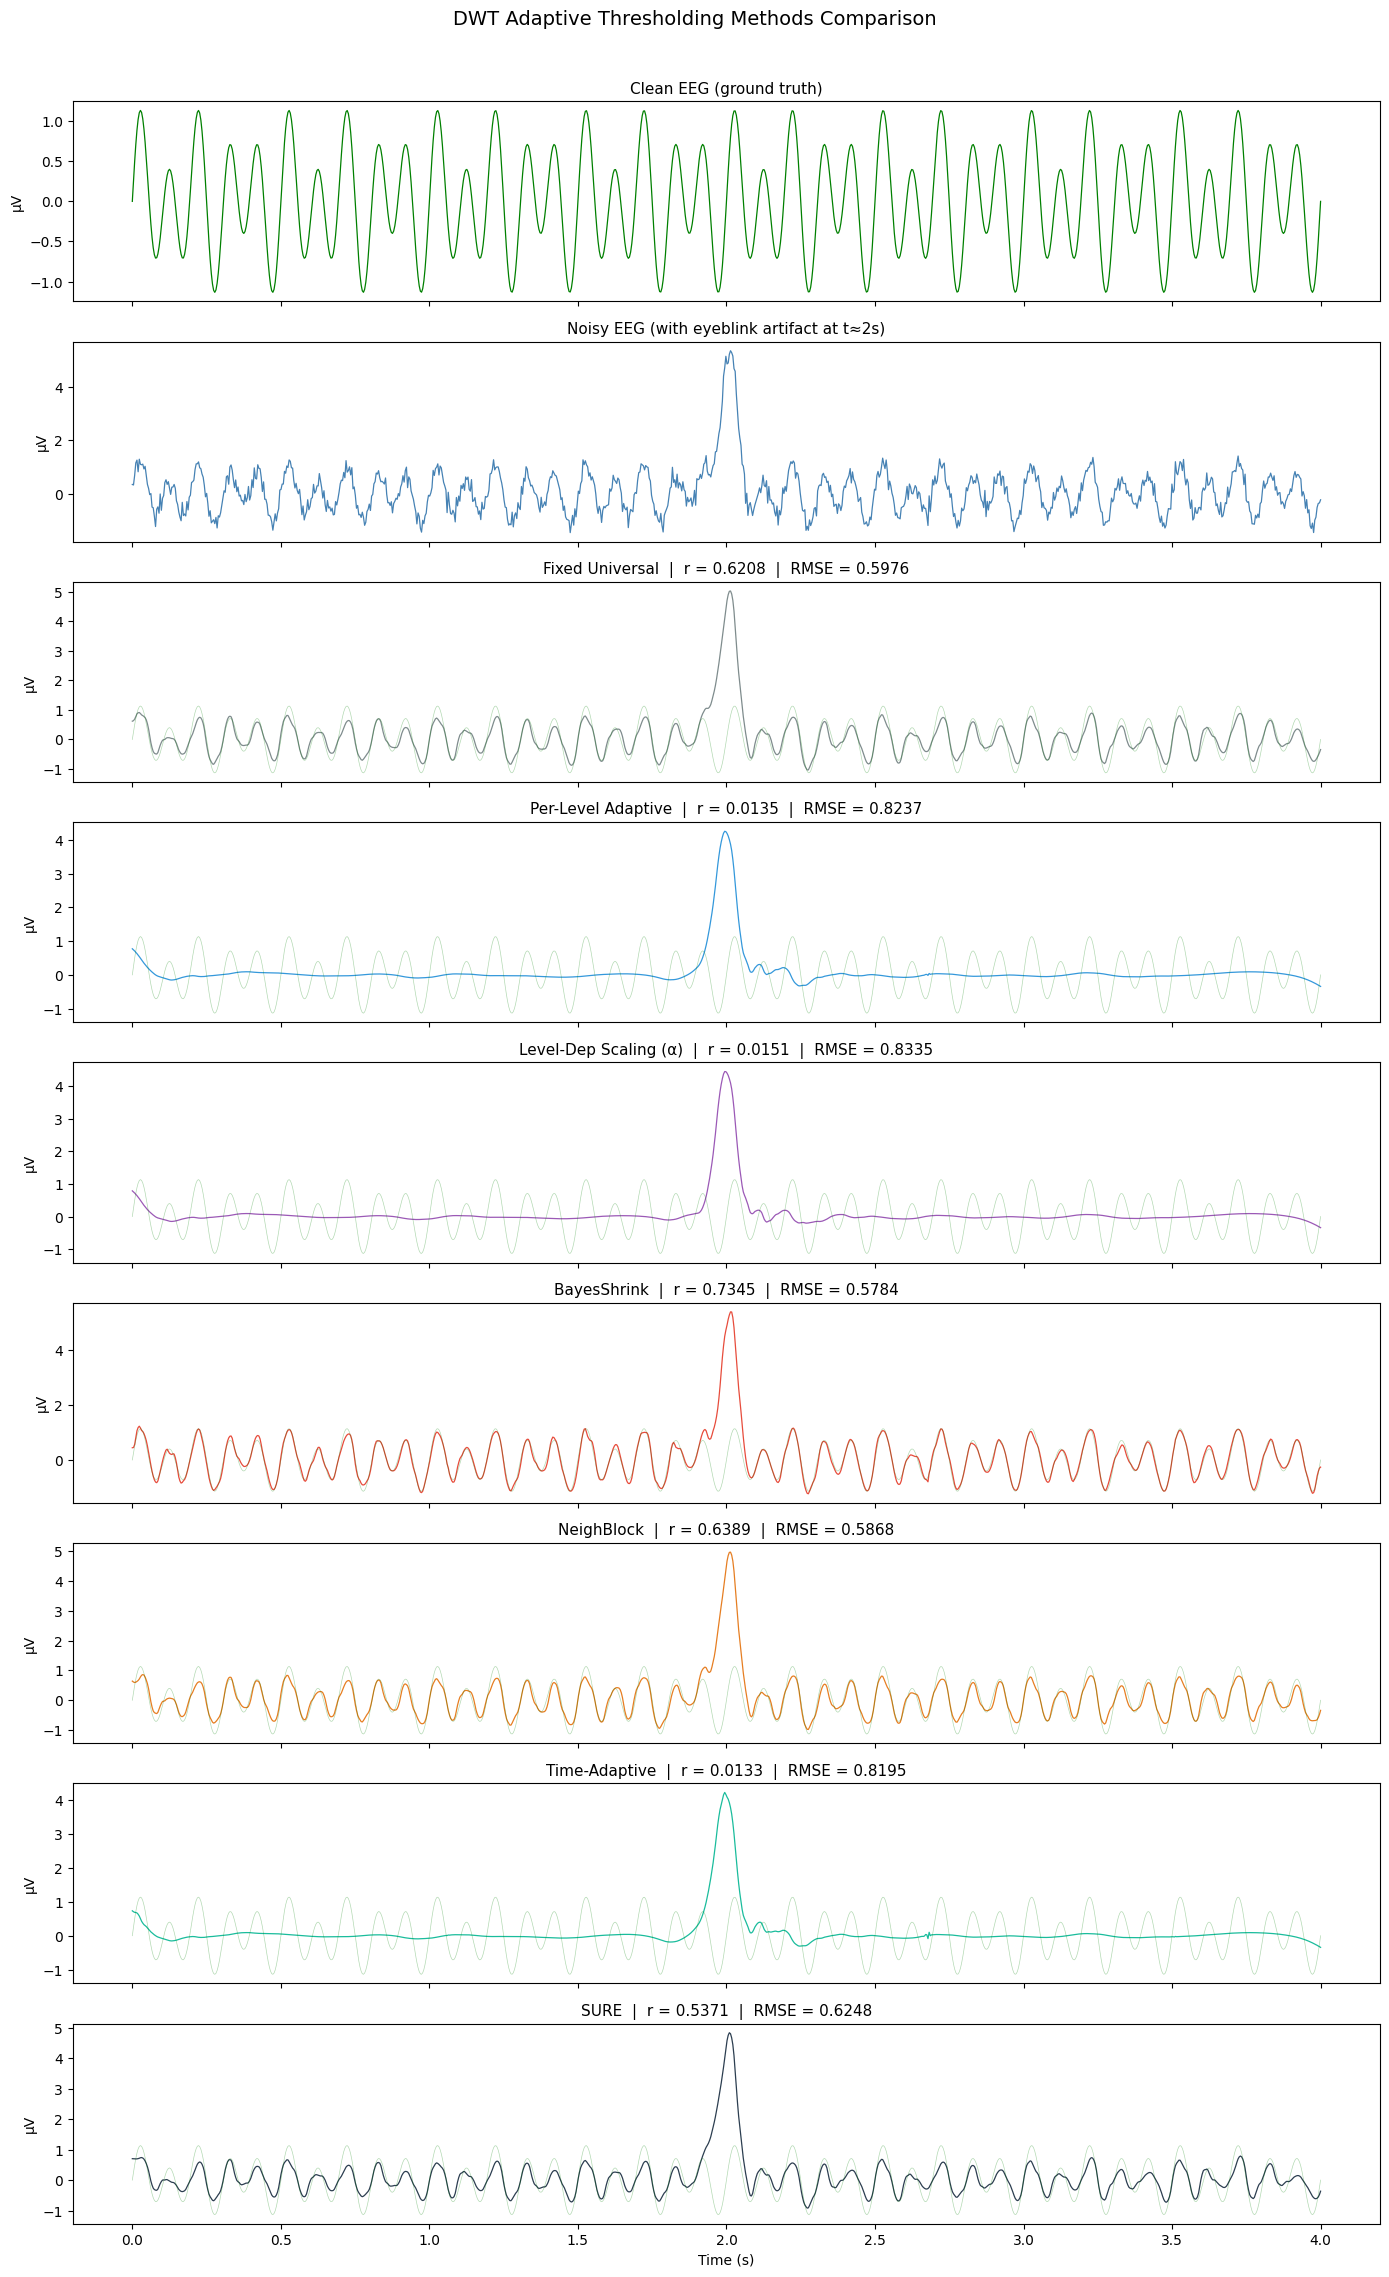

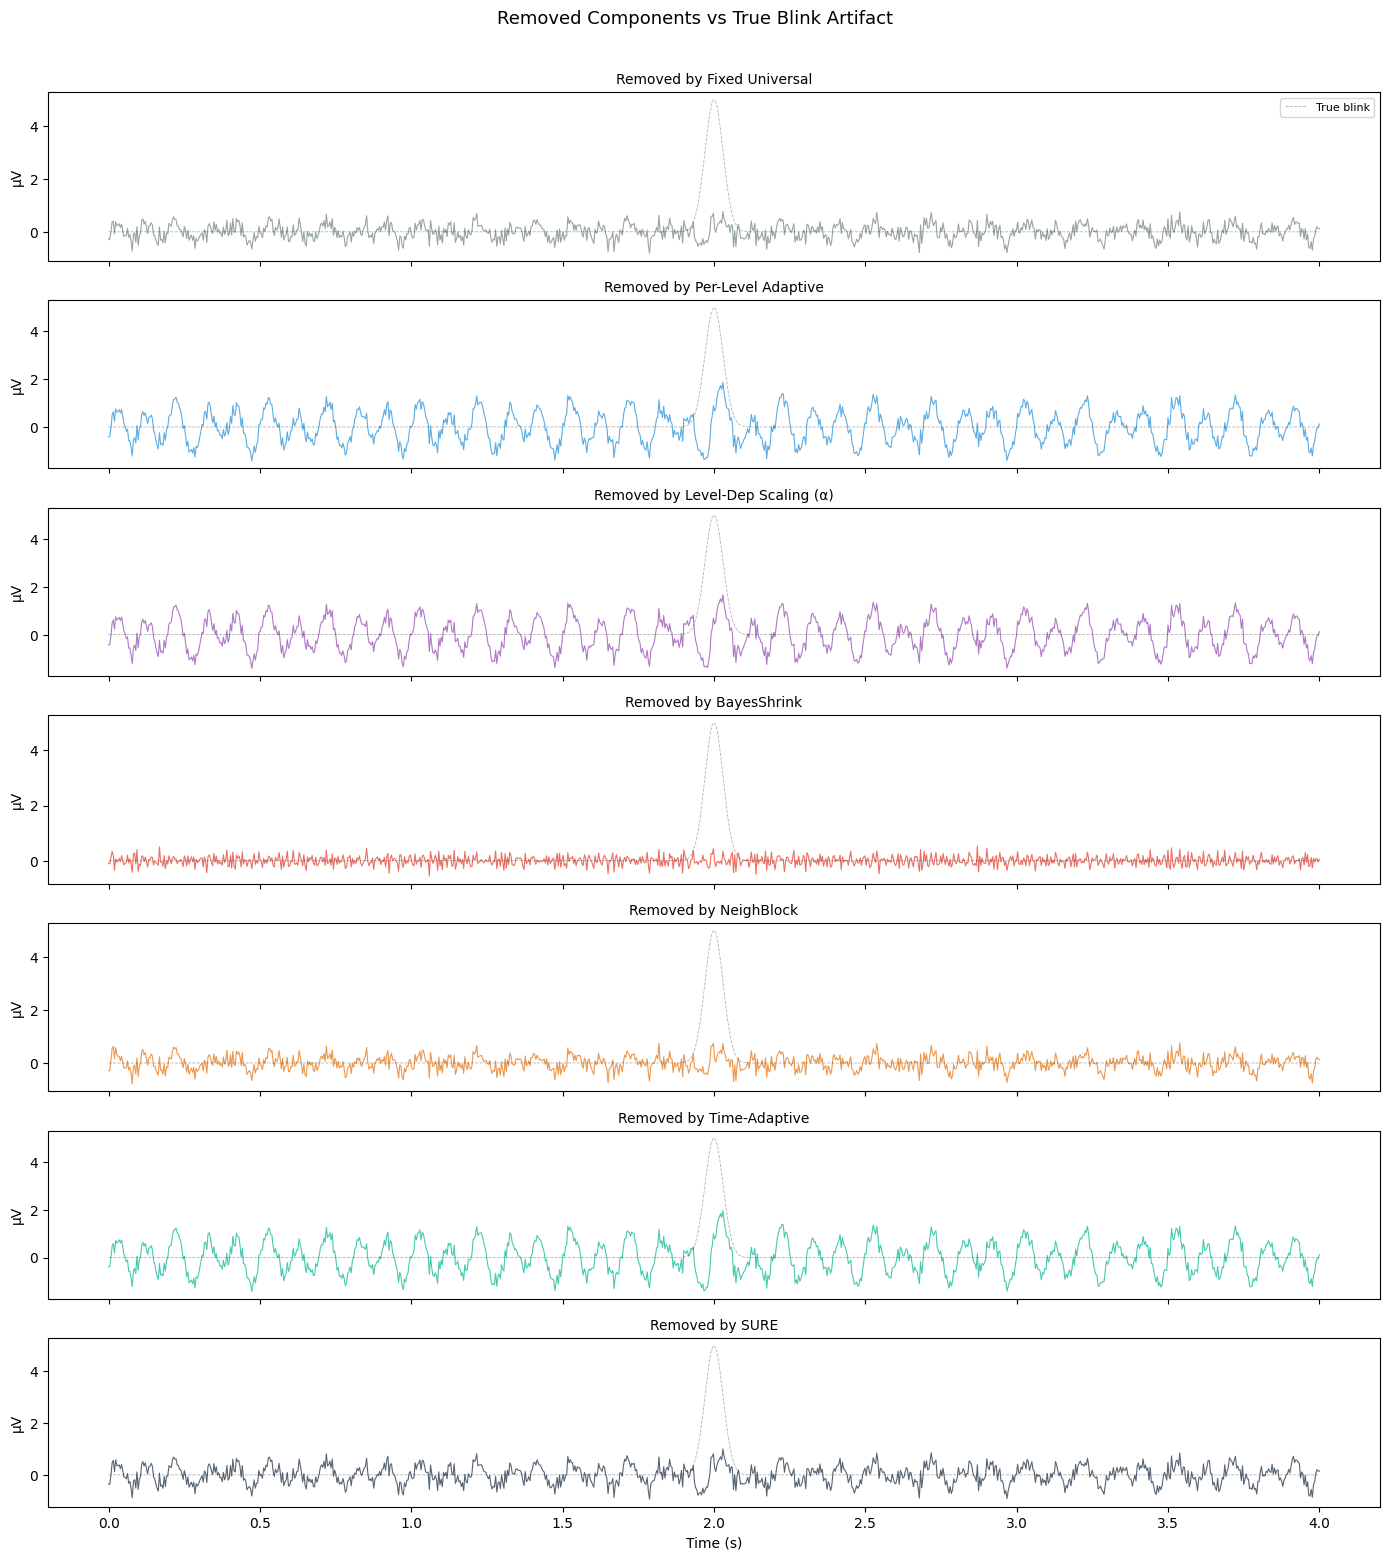

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.stats import pearsonr

# ═══════════════════════════════════════════════════════════════════════
# SIGNAL SETUP (same as before)
# ═══════════════════════════════════════════════════════════════════════
np.random.seed(0)
fs = 256
t = np.linspace(0, 4, fs * 4)

clean_eeg = 0.8 * np.sin(2 * np.pi * 10 * t) + 0.4 * np.sin(2 * np.pi * 6 * t)
blink = 5 * np.exp(-((t - 2.0) ** 2) / (2 * 0.03**2))
noisy_eeg = clean_eeg + blink + 0.2 * np.random.randn(len(t))

wavelet = "db5"
level = 5

# ═══════════════════════════════════════════════════════════════════════
# METHOD 0: Fixed Universal Threshold (baseline)
# ═══════════════════════════════════════════════════════════════════════
coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)
sigma_global = np.median(np.abs(coeffs[-1])) / 0.6745
thresh_global = sigma_global * np.sqrt(2 * np.log(len(noisy_eeg)))
ct0 = [coeffs[0]] + [pywt.threshold(c, value=thresh_global, mode="soft") for c in coeffs[1:]]
denoised_fixed = pywt.waverec(ct0, wavelet)[:len(t)]

# ═══════════════════════════════════════════════════════════════════════
# METHOD 1: Per-Level Adaptive Threshold
# ═══════════════════════════════════════════════════════════════════════
coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)
ct1 = [coeffs[0]]
for d in coeffs[1:]:
    sigma_j = np.median(np.abs(d)) / 0.6745
    thresh_j = sigma_j * np.sqrt(2 * np.log(len(d)))
    ct1.append(pywt.threshold(d, value=thresh_j, mode="soft"))
denoised_adaptive = pywt.waverec(ct1, wavelet)[:len(t)]

# ═══════════════════════════════════════════════════════════════════════
# METHOD 2: Level-Dependent Scaling (alpha_j)
# ═══════════════════════════════════════════════════════════════════════
# D1=coeffs[-1] (highest freq) → alpha=1.5
# D5=coeffs[1]  (lowest detail) → alpha=0.5
alphas = [0.5, 0.7, 1.0, 1.3, 1.5]  # D5, D4, D3, D2, D1

coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)
ct2 = [coeffs[0]]
for d, alpha in zip(coeffs[1:], alphas):
    sigma_j = np.median(np.abs(d)) / 0.6745
    thresh_j = alpha * sigma_j * np.sqrt(2 * np.log(len(d)))
    ct2.append(pywt.threshold(d, value=thresh_j, mode="soft"))
denoised_scaled = pywt.waverec(ct2, wavelet)[:len(t)]

# ═══════════════════════════════════════════════════════════════════════
# METHOD 3: BayesShrink
# T_j = sigma_n^2 / sigma_x  (per level)
# ═══════════════════════════════════════════════════════════════════════
coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)
sigma_n = np.median(np.abs(coeffs[-1])) / 0.6745  # noise std from D1

ct3 = [coeffs[0]]
for d in coeffs[1:]:
    sigma_d2 = np.mean(d**2)                        # total variance at this level
    sigma_x = np.sqrt(max(sigma_d2 - sigma_n**2, 0))  # signal std
    if sigma_x == 0:
        thresh_j = np.max(np.abs(d))  # kill everything if no signal detected
    else:
        thresh_j = sigma_n**2 / sigma_x
    ct3.append(pywt.threshold(d, value=thresh_j, mode="soft"))
denoised_bayes = pywt.waverec(ct3, wavelet)[:len(t)]

# ═══════════════════════════════════════════════════════════════════════
# METHOD 4: NeighBlock Thresholding
# Threshold blocks of neighbouring coefficients together
# ═══════════════════════════════════════════════════════════════════════
def neighblock_threshold(d, sigma_n, block_size=None):
    N = len(d)
    if block_size is None:
        block_size = max(1, int(np.sqrt(N)))  # sqrt(N) block size
    thresh = sigma_n * np.sqrt(2 * np.log(N))
    d_out = d.copy()
    for start in range(0, N, block_size):
        end = min(start + block_size, N)
        block = d[start:end]
        block_energy = np.sqrt(np.sum(block**2))
        if block_energy <= thresh * np.sqrt(len(block)):
            d_out[start:end] = 0.0
        else:
            # soft-shrink the block norm
            factor = max(0, 1 - (thresh * np.sqrt(len(block))) / block_energy)
            d_out[start:end] = block * factor
    return d_out

coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)
sigma_n = np.median(np.abs(coeffs[-1])) / 0.6745

ct4 = [coeffs[0]]
for d in coeffs[1:]:
    ct4.append(neighblock_threshold(d, sigma_n))
denoised_neighblock = pywt.waverec(ct4, wavelet)[:len(t)]

# ═══════════════════════════════════════════════════════════════════════
# METHOD 5: Time-Adaptive (Windowed) Thresholding
# Compute local thresholds over sliding windows
# ═══════════════════════════════════════════════════════════════════════
def time_adaptive_threshold(d, window_size=None):
    N = len(d)
    if window_size is None:
        window_size = max(8, N // 4)
    d_out = d.copy()
    half_win = window_size // 2
    for i in range(N):
        start = max(0, i - half_win)
        end = min(N, i + half_win)
        local_block = d[start:end]
        sigma_local = np.median(np.abs(local_block)) / 0.6745
        thresh_local = sigma_local * np.sqrt(2 * np.log(len(local_block)))
        if np.abs(d[i]) < thresh_local:
            d_out[i] = 0.0
        else:
            d_out[i] = np.sign(d[i]) * (np.abs(d[i]) - thresh_local)
    return d_out


# ═══════════════════════════════════════════════════════════════════════
# METHOD 6: SURE (Stein's Unbiased Risk Estimate)
# Picks the threshold that minimizes estimated MSE per level
# ═══════════════════════════════════════════════════════════════════════
def sure_threshold(d):
    """Compute optimal threshold minimizing SURE risk."""
    N = len(d)
    d_sorted2 = np.sort(d**2)
    cumsum = np.cumsum(d_sorted2)
    risks = (N - 2 * np.arange(1, N + 1) + cumsum) / N
    best_idx = np.argmin(risks)
    return np.sqrt(d_sorted2[best_idx])

coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)
ct6 = [coeffs[0]]
for d in coeffs[1:]:
    thresh_j = sure_threshold(d)
    ct6.append(pywt.threshold(d, value=thresh_j, mode="soft"))
denoised_sure = pywt.waverec(ct6, wavelet)[:len(t)]



# ═══════════════════════════════════════════════════════════════════════
# COLLECT ALL METHODS & COMPUTE METRICS
# ═══════════════════════════════════════════════════════════════════════
methods = {
    "Fixed Universal":       denoised_fixed,
    "Per-Level Adaptive":    denoised_adaptive,
    "Level-Dep Scaling (α)": denoised_scaled,
    "BayesShrink":           denoised_bayes,
    "NeighBlock":            denoised_neighblock,
    "Time-Adaptive":         denoised_timeadapt,
    "SURE":                  denoised_sure,
}

colors = ["#7f8c8d", "#3498db", "#9b59b6", "#e74c3c", "#e67e22", "#1abc9c", "#2c3e50"]


print(f"{'Method':<25} {'Pearson r':>10} {'RMSE':>10}")
print("─" * 47)
metrics = {}
for name, den in methods.items():
    r, _ = pearsonr(clean_eeg, den)
    rmse = np.sqrt(np.mean((clean_eeg - den)**2))
    metrics[name] = (r, rmse)
    print(f"{name:<25} {r:10.4f} {rmse:10.4f}")

# ═══════════════════════════════════════════════════════════════════════
# PLOT: All methods compared
# ═══════════════════════════════════════════════════════════════════════
n_methods = len(methods)
fig, axes = plt.subplots(n_methods + 2, 1, figsize=(14, 2.5 * (n_methods + 2)), sharex=True)

# Row 0: Clean EEG
axes[0].plot(t, clean_eeg, color="green", linewidth=0.9)
axes[0].set_title("Clean EEG (ground truth)", fontsize=11)
axes[0].set_ylabel("μV")

# Row 1: Noisy EEG
axes[1].plot(t, noisy_eeg, color="steelblue", linewidth=0.9)
axes[1].set_title("Noisy EEG (with eyeblink artifact at t≈2s)", fontsize=11)
axes[1].set_ylabel("μV")

# Rows 2+: Each denoising method
for idx, ((name, den), color) in enumerate(zip(methods.items(), colors)):
    ax = axes[idx + 2]
    r, rmse = metrics[name]
    ax.plot(t, den, color=color, linewidth=0.9)
    ax.plot(t, clean_eeg, color="green", linewidth=0.5, alpha=0.3)
    ax.set_title(f"{name}  |  r = {r:.4f}  |  RMSE = {rmse:.4f}", fontsize=11)
    ax.set_ylabel("μV")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("DWT Adaptive Thresholding Methods Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT: Removed components for each method
# ═══════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(n_methods, 1, figsize=(14, 2.2 * n_methods), sharex=True)

for idx, ((name, den), color) in enumerate(zip(methods.items(), colors)):
    removed = noisy_eeg - den
    axes2[idx].plot(t, removed, color=color, linewidth=0.8, alpha=0.8)
    axes2[idx].plot(t, blink, color="black", linewidth=0.6, alpha=0.3, linestyle="--", label="True blink")
    axes2[idx].set_title(f"Removed by {name}", fontsize=10)
    axes2[idx].set_ylabel("μV")
    if idx == 0:
        axes2[idx].legend(fontsize=8)

axes2[-1].set_xlabel("Time (s)")
fig2.suptitle("Removed Components vs True Blink Artifact", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# 5. Empirical Mode Decomposition (EMD)
---
Unlike Wavelet Transforms which use predefined basis functions, **EMD** is a data-driven approach. It discovers oscillatory modes directly from the signal itself.

### What are IMFs?
EMD decomposes a signal into **Intrinsic Mode Functions (IMFs)**.

Mode: Refers to a portion of the signal that represents a specific oscillation or trend.

Decomposition: The process of separating a signal into simpler, physically meaningful components.

 IMFs are the components extracted from the signal during EMD. Each IMF represents a simple oscillatory mode embedded in the data.

Each IMF is:
*   **Locally symmetric**
*   **Narrow-band-ish**
*   **Oscillatory**

The signal is represented as:
$$\text{Signal} = \sum_{i=1}^{n} \text{IMF}_i + \text{residual}$$


IMFs: Ordered from highest to lowest frequency (smallest to largest scales).

Residual: Represents the trend or mean of the signal after all IMFs are extracted.

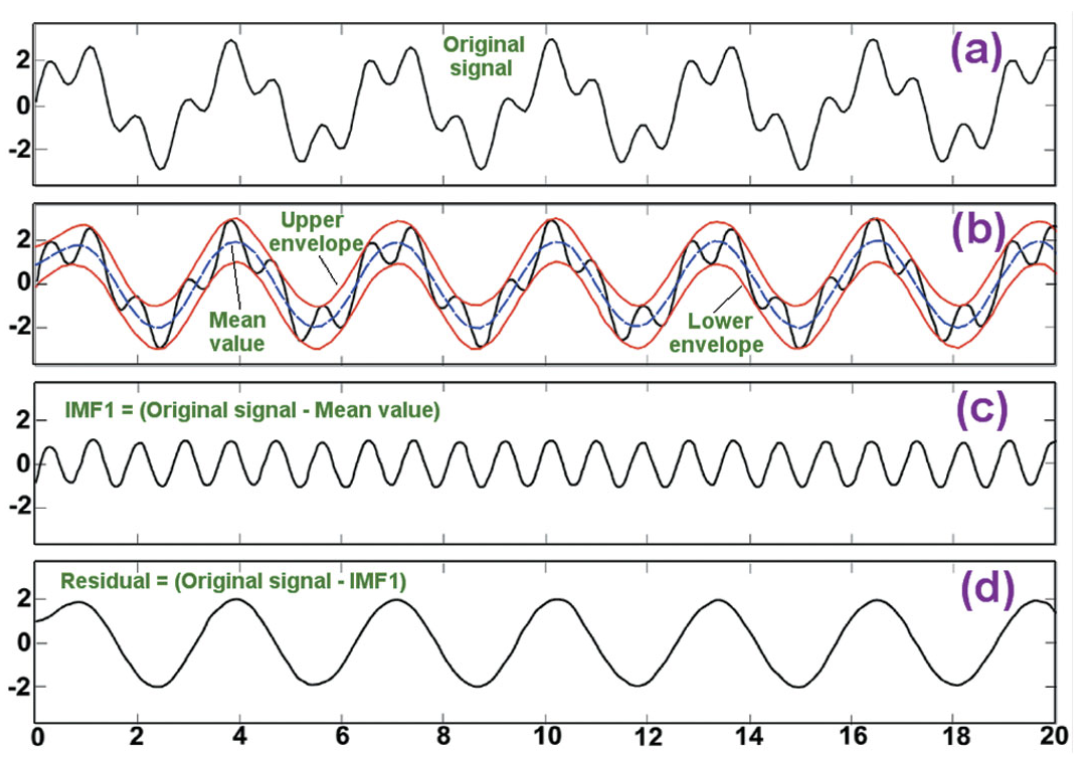

### Why use EMD for EEG?
*   **No Assumptions:** It does not assume sinusoids (like Fourier) or wavelets.
*   **Biological Fit:** Modes emerge from the signal, making it ideal for **neural oscillations** which are often messy, non-linear, and non-stationary.

### The Major Issue: Mode Mixing
A common problem in EMD is **Mode Mixing**, where:
1.  A single IMF contains multiple disparate frequencies.
2.  A single frequency component is split across multiple IMFs.
*This is especially prevalent in noisy data.*

## Mixture of signals

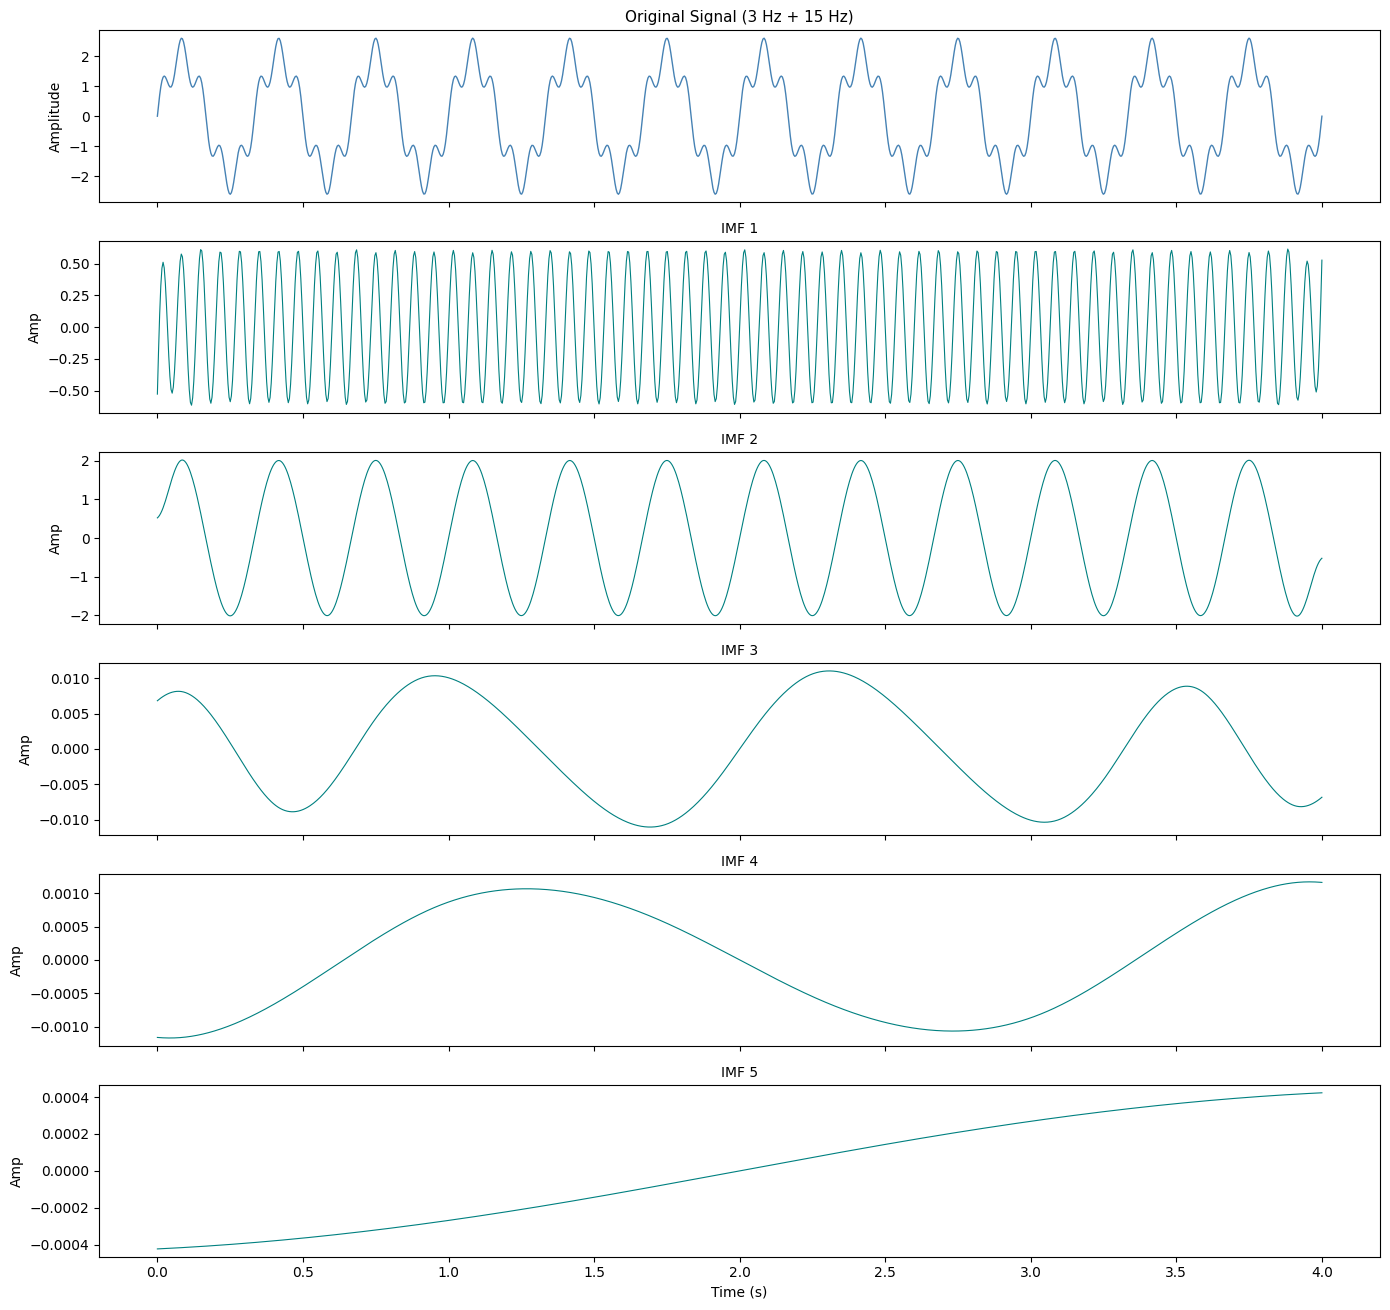

  IMF Sample Entropy Kurtosis
IMF 1         0.2520  -1.4957
IMF 2         0.2075  -1.4945
IMF 3         0.0571  -1.4567
IMF 4         0.0208  -1.5030
IMF 5         0.0029  -1.4292

Kurtosis threshold: 1.5
  IMF 1: kurtosis=-1.4957  → KEEP
  IMF 2: kurtosis=-1.4945  → KEEP
  IMF 3: kurtosis=-1.4567  → KEEP
  IMF 4: kurtosis=-1.5030  → REJECT
  IMF 5: kurtosis=-1.4292  → KEEP


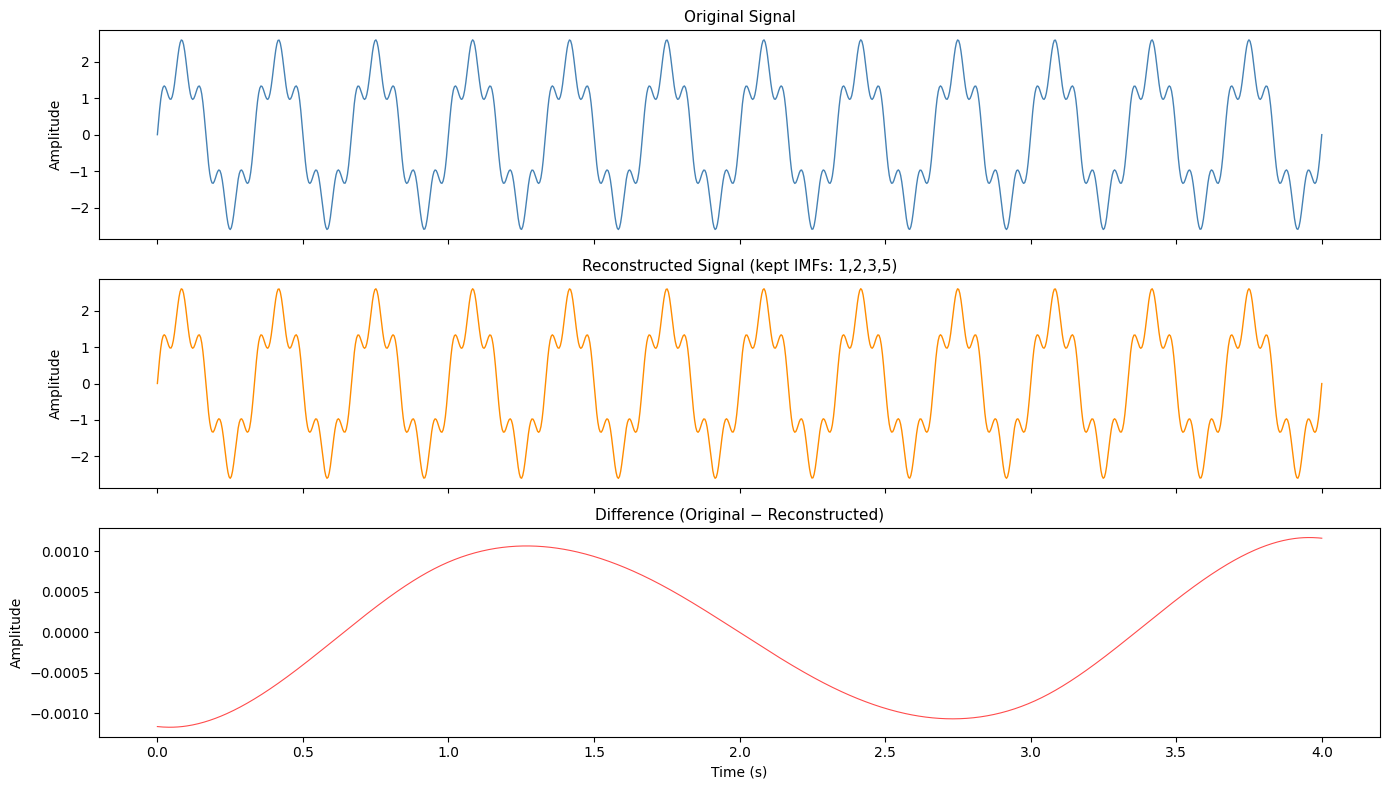

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from scipy.stats import kurtosis
import pandas as pd

# ═══════════════════════════════════════════════════════════════════════
# 1. CREATE THE SIGNAL
# ═══════════════════════════════════════════════════════════════════════
fs = 256
t = np.linspace(0, 4, fs * 4)

slow = 2.0 * np.sin(2 * np.pi * 3 * t)     # 3 Hz — slow wave
fast = 0.6 * np.sin(2 * np.pi * 15 * t)    # 15 Hz — fast ripple on top
signal = slow + fast

# ═══════════════════════════════════════════════════════════════════════
# 2. APPLY EMD
# ═══════════════════════════════════════════════════════════════════════
emd = EMD()
imfs = emd.emd(signal, t)
n_imfs = imfs.shape[0]

# ═══════════════════════════════════════════════════════════════════════
# 3. PLOT IMFs
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 2.2 * (n_imfs + 1)), sharex=True)
axes[0].plot(t, signal, color="steelblue", lw=1)
axes[0].set_title("Original Signal (3 Hz + 15 Hz)", fontsize=11)
axes[0].set_ylabel("Amplitude")

for i in range(n_imfs):
    axes[i + 1].plot(t, imfs[i], color="teal", lw=0.8)
    axes[i + 1].set_title(f"IMF {i + 1}", fontsize=10)
    axes[i + 1].set_ylabel("Amp")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# 4. SAMPLE ENTROPY & KURTOSIS TABLE
# ═══════════════════════════════════════════════════════════════════════
def sample_entropy(x, m=2, r_frac=0.2):
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = r_frac * np.std(x)
    if r == 0 or N < m + 2:
        return 0.0
    def _count(tl):
        templates = np.lib.stride_tricks.sliding_window_view(x, tl)
        count = 0
        for i in range(len(templates)):
            dists = np.max(np.abs(templates[i] - templates), axis=1)
            count += np.sum(dists < r) - 1
        return count
    A, B = _count(m + 1), _count(m)
    if B == 0 or A == 0:
        return 0.0
    return -np.log(A / B)

entropies = [sample_entropy(imf) for imf in imfs]
kurts = [kurtosis(imf) for imf in imfs]

df = pd.DataFrame({
    "IMF": [f"IMF {i+1}" for i in range(n_imfs)],
    "Sample Entropy": [f"{e:.4f}" for e in entropies],
    "Kurtosis": [f"{k:.4f}" for k in kurts],
})
print(df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════
# 5. KURTOSIS THRESHOLD → RECONSTRUCT SIGNAL
# ═══════════════════════════════════════════════════════════════════════
kurt_threshold = 1.5  # keep IMFs with |kurtosis| below this
kurts_arr = np.array(kurts)
keep_mask = np.abs(kurts_arr) < kurt_threshold

print(f"\nKurtosis threshold: {kurt_threshold}")
for i in range(n_imfs):
    tag = "KEEP" if keep_mask[i] else "REJECT"
    print(f"  IMF {i+1}: kurtosis={kurts_arr[i]:.4f}  → {tag}")

reconstructed = np.sum(imfs[keep_mask], axis=0)

# ═══════════════════════════════════════════════════════════════════════
# 6. PLOT ORIGINAL vs RECONSTRUCTED
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, signal, color="steelblue", lw=1)
axes[0].set_title("Original Signal", fontsize=11)
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, reconstructed, color="darkorange", lw=1)
kept_ids = ",".join(str(i+1) for i in range(n_imfs) if keep_mask[i])
axes[1].set_title(f"Reconstructed Signal (kept IMFs: {kept_ids})", fontsize=11)
axes[1].set_ylabel("Amplitude")

axes[2].plot(t, signal - reconstructed, color="red", lw=0.8, alpha=0.7)
axes[2].set_title("Difference (Original − Reconstructed)", fontsize=11)
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


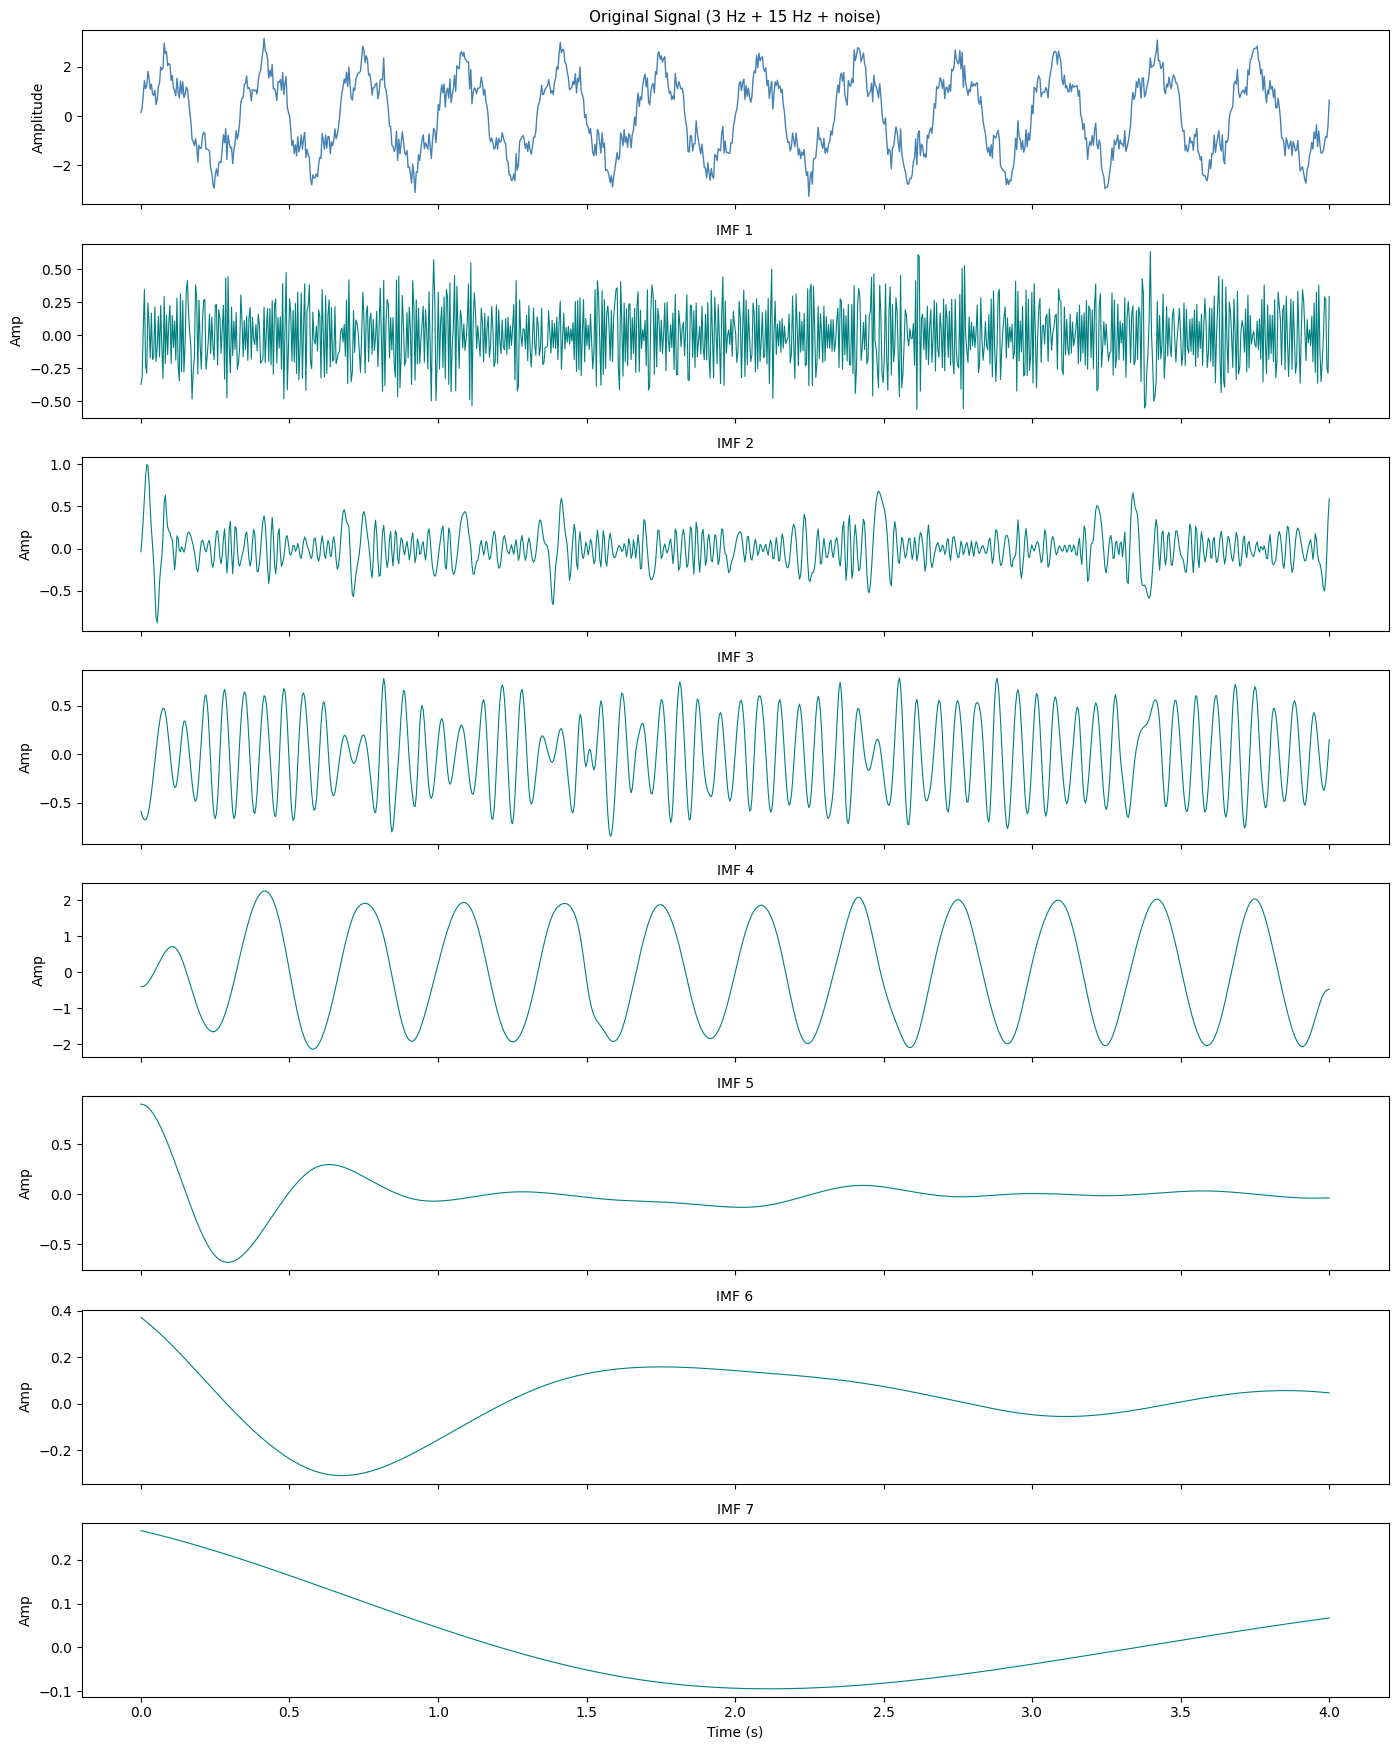

  IMF Sample Entropy Kurtosis
IMF 1         1.2915  -0.8770
IMF 2         0.9733   1.9762
IMF 3         0.5611  -1.1623
IMF 4         0.2288  -1.4331
IMF 5         0.0303   7.0724
IMF 6         0.0288   0.1367
IMF 7         0.0102  -0.1407

Kurtosis threshold: 1.5
  IMF 1: kurtosis=-0.8770  → KEEP
  IMF 2: kurtosis=1.9762  → REJECT
  IMF 3: kurtosis=-1.1623  → KEEP
  IMF 4: kurtosis=-1.4331  → KEEP
  IMF 5: kurtosis=7.0724  → REJECT
  IMF 6: kurtosis=0.1367  → KEEP
  IMF 7: kurtosis=-0.1407  → KEEP


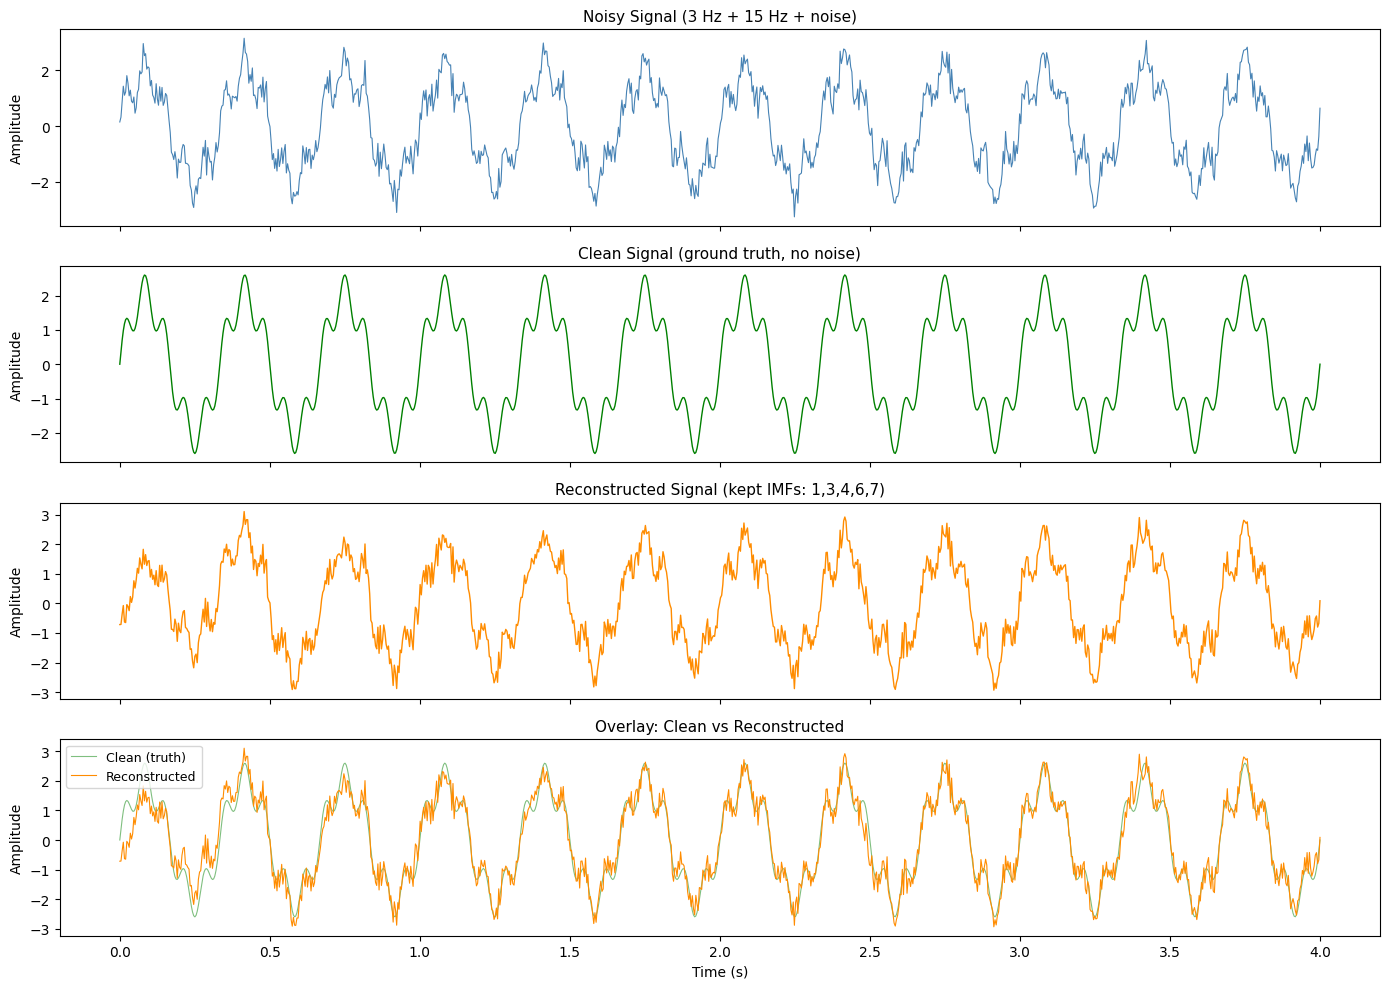


RMSE (clean vs reconstructed): 0.3717


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from scipy.stats import kurtosis
import pandas as pd

# ═══════════════════════════════════════════════════════════════════════
# 1. CREATE THE SIGNAL (with noise)
# ═══════════════════════════════════════════════════════════════════════
np.random.seed(42)
fs = 256
t = np.linspace(0, 4, fs * 4)

slow = 2.0 * np.sin(2 * np.pi * 3 * t)     # 3 Hz — slow wave
fast = 0.6 * np.sin(2 * np.pi * 15 * t)    # 15 Hz — fast ripple on top
noise = 0.3 * np.random.randn(len(t))       # Gaussian noise
signal_clean = slow + fast
signal = slow + fast + noise

# ═══════════════════════════════════════════════════════════════════════
# 2. APPLY EMD
# ═══════════════════════════════════════════════════════════════════════
emd = EMD()
imfs = emd.emd(signal, t)
n_imfs = imfs.shape[0]

# ═══════════════════════════════════════════════════════════════════════
# 3. PLOT IMFs
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 2.2 * (n_imfs + 1)), sharex=True)
axes[0].plot(t, signal, color="steelblue", lw=1)
axes[0].set_title("Original Signal (3 Hz + 15 Hz + noise)", fontsize=11)
axes[0].set_ylabel("Amplitude")

for i in range(n_imfs):
    axes[i + 1].plot(t, imfs[i], color="teal", lw=0.8)
    axes[i + 1].set_title(f"IMF {i + 1}", fontsize=10)
    axes[i + 1].set_ylabel("Amp")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# 4. SAMPLE ENTROPY & KURTOSIS TABLE
# ═══════════════════════════════════════════════════════════════════════
def sample_entropy(x, m=2, r_frac=0.2):
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = r_frac * np.std(x)
    if r == 0 or N < m + 2:
        return 0.0
    def _count(tl):
        templates = np.lib.stride_tricks.sliding_window_view(x, tl)
        count = 0
        for i in range(len(templates)):
            dists = np.max(np.abs(templates[i] - templates), axis=1)
            count += np.sum(dists < r) - 1
        return count
    A, B = _count(m + 1), _count(m)
    if B == 0 or A == 0:
        return 0.0
    return -np.log(A / B)

entropies = [sample_entropy(imf) for imf in imfs]
kurts = [kurtosis(imf) for imf in imfs]

df = pd.DataFrame({
    "IMF": [f"IMF {i+1}" for i in range(n_imfs)],
    "Sample Entropy": [f"{e:.4f}" for e in entropies],
    "Kurtosis": [f"{k:.4f}" for k in kurts],
})
print(df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════
# 5. KURTOSIS THRESHOLD → RECONSTRUCT SIGNAL
# ═══════════════════════════════════════════════════════════════════════
kurt_threshold = 1.5
kurts_arr = np.array(kurts)
keep_mask = np.abs(kurts_arr) < kurt_threshold

print(f"\nKurtosis threshold: {kurt_threshold}")
for i in range(n_imfs):
    tag = "KEEP" if keep_mask[i] else "REJECT"
    print(f"  IMF {i+1}: kurtosis={kurts_arr[i]:.4f}  → {tag}")

reconstructed = np.sum(imfs[keep_mask], axis=0)

# ═══════════════════════════════════════════════════════════════════════
# 6. PLOT: ORIGINAL vs CLEAN vs RECONSTRUCTED
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, signal, color="steelblue", lw=0.8)
axes[0].set_title("Noisy Signal (3 Hz + 15 Hz + noise)", fontsize=11)
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, signal_clean, color="green", lw=1)
axes[1].set_title("Clean Signal (ground truth, no noise)", fontsize=11)
axes[1].set_ylabel("Amplitude")

kept_ids = ",".join(str(i+1) for i in range(n_imfs) if keep_mask[i])
axes[2].plot(t, reconstructed, color="darkorange", lw=1)
axes[2].set_title(f"Reconstructed Signal (kept IMFs: {kept_ids})", fontsize=11)
axes[2].set_ylabel("Amplitude")

axes[3].plot(t, signal_clean, color="green", lw=0.8, alpha=0.5, label="Clean (truth)")
axes[3].plot(t, reconstructed, color="darkorange", lw=0.8, label="Reconstructed")
axes[3].set_title("Overlay: Clean vs Reconstructed", fontsize=11)
axes[3].set_ylabel("Amplitude")
axes[3].set_xlabel("Time (s)")
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

# RMSE between clean and reconstructed
rmse = np.sqrt(np.mean((signal_clean - reconstructed) ** 2))
print(f"\nRMSE (clean vs reconstructed): {rmse:.4f}")


# 6. Improving EMD: EEMD & CEEMDAN
---
To solve the "Mode Mixing" problem, we use ensemble-based approaches that leverage noise to stabilize the decomposition.

### A. Ensemble EMD (EEMD)
Counterintuitively, **adding noise improves robustness**. 
*   **How it works:** We add random white noise to the signal many times. For each noisy realization, we run EMD and then average the corresponding IMFs.
*   **Intuition:** Noise fills the time-frequency space uniformly, which helps "guide" the decomposition and prevents frequencies from hopping between modes.

**The Workflow:**
1. $x(t) + w_i(t)$ (Add noise)
2. Run EMD repeatedly to get $IMF_i^{(k)}$
3. $\bar{IMF}_i$ (Average results)


![EEMD](images/EEMD.png)

### B. CEEMDAN
**Complete Ensemble EMD with Adaptive Noise (CEEMDAN)** is a further refinement. It uses complementary positive and negative noise pairs to reduce reconstruction error and computational cost, providing a more complete and stable decomposition.

![CEEMDAN](images/CEEMDAN.png)


  EMD  (8 IMFs)
IMF      SampEn      |r|       E%     Kurt    DomHz | Entro  Corre  Energ  Kurto  Frequ  Combi
--------------------------------------------------------------------------------
IMF 1    1.2635   0.0161   47.35%     1.96    60.00 |     .    ##     .     .     .     . 
IMF 2    0.7707   0.0375    9.72%    -0.92    30.00 |     .    ##     .     .     .     . 
IMF 3    0.6099   0.3899   39.75%    -1.31    10.00 |     .     .     .     .     .     . 
IMF 4    0.4443   0.0456    2.36%     2.85     5.00 |     .    ##     .     .     .     . 
IMF 5    0.2361   0.0059    0.67%     0.66     3.00 |    ##    ##     .     .     .    ## 
IMF 6    0.0517   0.1113    0.11%    -0.72     1.00 |    ##     .     .     .    ##    ## 
IMF 7    0.0461   0.3578    0.01%    -1.21     1.00 |    ##     .     .     .    ##    ## 
IMF 8    0.0122   0.2181    0.02%    -1.13     1.00 |    ##     .     .     .    ##    ## 

  EEMD  (9 IMFs)
IMF      SampEn      |r|       E%     Kurt    DomHz | Entro  

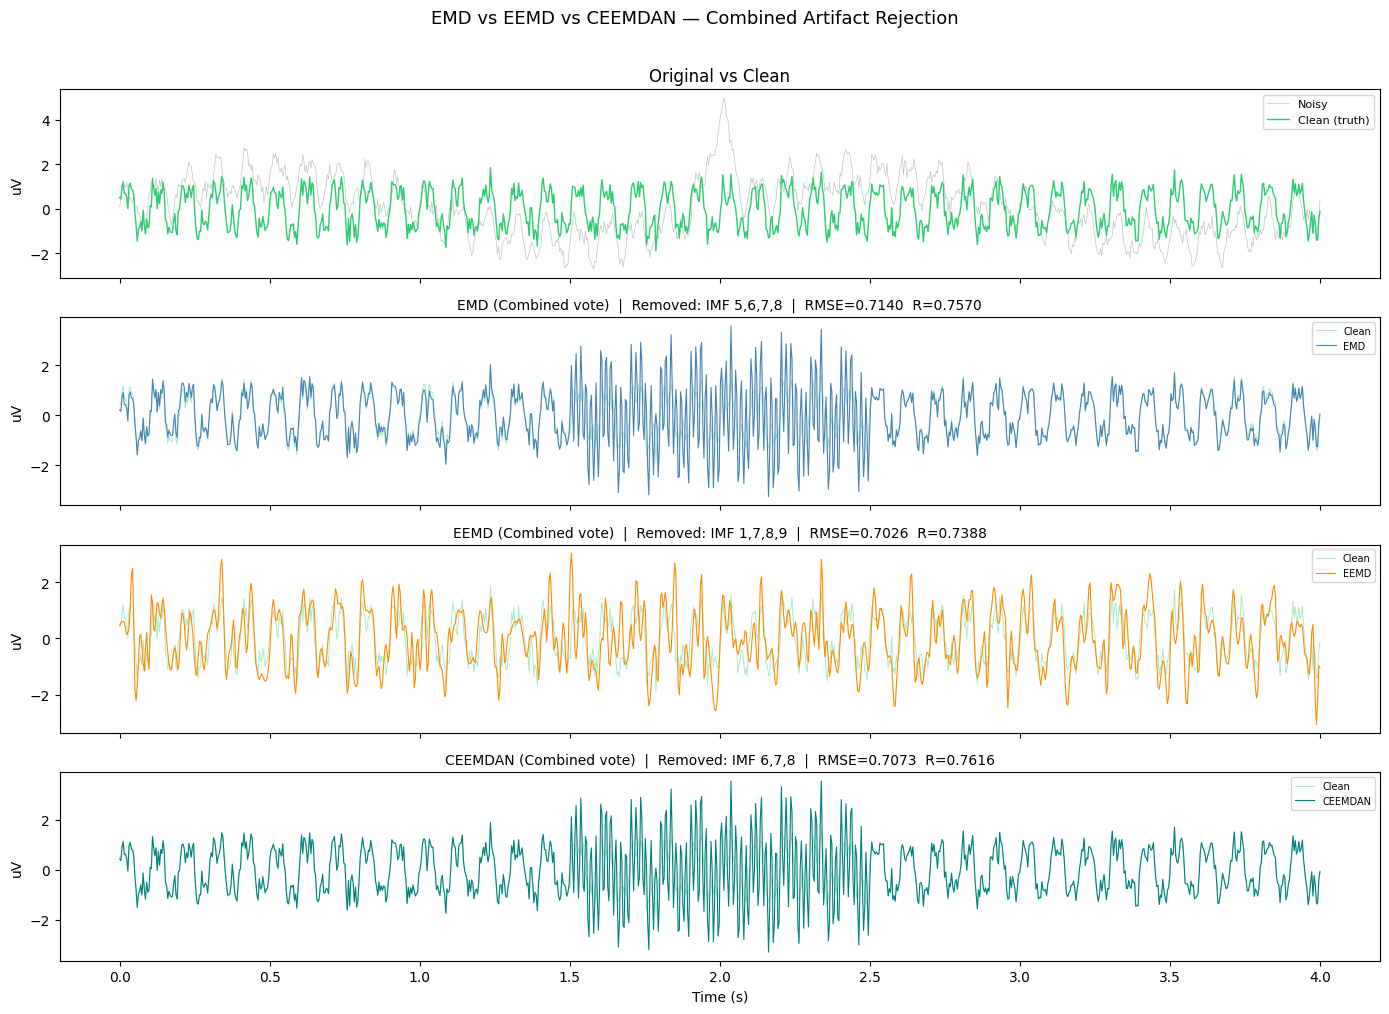

In [25]:
from scipy.stats import pearsonr, kurtosis


# Clean signal (ground truth — signal without the burst artifact)
# Realistic clean EEG: multiple rhythms with amplitude modulation
# Clean = signal without the intermittent burst artifact
clean = (np.sin(2 * np.pi * 10 * t)
         + 0.5 * np.sin(2 * np.pi * 30 * t)
         + 0.3 * np.random.RandomState(7).randn(len(t)))

def compute_all_masks(imfs, signal, fs):
    """Compute all 5 rejection masks + combined for a set of IMFs."""
    n = imfs.shape[0]

    # 1. Entropy
    ent = np.array([sample_entropy(imf[:200]) for imf in imfs])
    m_ent = largest_gap_mask(ent, low_is_artifact=True)

    # 2. Correlation
    corr = np.array([abs(pearsonr(imf, signal)[0]) for imf in imfs])
    m_corr = largest_gap_mask(corr, low_is_artifact=True)

    # 3. Energy
    energy = np.array([np.sum(imf**2) for imf in imfs])
    eratio = energy / energy.sum()
    m_energy = eratio > np.mean(eratio) + 2 * np.std(eratio)

    # 4. Kurtosis
    kurt = np.array([kurtosis(imf) for imf in imfs])
    m_kurt = kurt > 5

    # 5. Dominant frequency
    domf = []
    for imf in imfs:
        f, psd = welch(imf, fs=fs, nperseg=min(256, len(imf)))
        domf.append(f[np.argmax(psd)])
    domf = np.array(domf)
    m_freq = domf < 2.0

    # 6. Combined (2+ votes)
    votes = (m_ent.astype(int) + m_corr.astype(int) + m_energy.astype(int)
             + m_kurt.astype(int) + m_freq.astype(int))
    m_combined = votes >= 2

    return {
        'Entropy': m_ent, 'Correlation': m_corr, 'Energy': m_energy,
        'Kurtosis': m_kurt, 'Frequency': m_freq, 'Combined': m_combined,
    }, {'ent': ent, 'corr': corr, 'eratio': eratio, 'kurt': kurt, 'domf': domf, 'votes': votes}


# --- Run rejection on all three decompositions ---
decompositions = [
    ('EMD',     imfs_emd),
    ('EEMD',    imfs_eemd),
    ('CEEMDAN', imfs_ceemdan),
]

all_results = {}
for dec_name, imfs in decompositions:
    masks, metrics = compute_all_masks(imfs,signal , fs)
    all_results[dec_name] = {'imfs': imfs, 'masks': masks, 'metrics': metrics}

    # Print diagnostics
    n_imfs = imfs.shape[0]
    print(f"\n{'='*80}")
    print(f"  {dec_name}  ({n_imfs} IMFs)")
    print(f"{'='*80}")
    print(f"{'IMF':<6} {'SampEn':>8} {'|r|':>8} {'E%':>8} {'Kurt':>8} {'DomHz':>8} | ", end="")
    print("  ".join(f"{m[:5]:>5}" for m in masks))
    print("-" * 80)
    for i in range(n_imfs):
        print(f"IMF {i+1:<2} {metrics['ent'][i]:8.4f} {metrics['corr'][i]:8.4f} "
              f"{metrics['eratio'][i]*100:7.2f}% {metrics['kurt'][i]:8.2f} "
              f"{metrics['domf'][i]:8.2f} | ", end="")
        for name, mask in masks.items():
            tag = "  ##" if mask[i] else "   ."
            print(f" {tag} ", end="")
        print()


    # --- Grand comparison: RMSE & R for every decomposition x rejection method ---
print(f"\n{'='*70}")
print(f"{'Decomposition':<12} {'Rejection':<15} {'Removed':<18} {'RMSE':>8} {'R':>8}")
print(f"{'='*70}")

summary_results = {}
for dec_name, data in all_results.items():
    imfs = data['imfs']
    for rej_name, mask in data['masks'].items():
        recon = np.sum(imfs[~mask], axis=0)
        n = min(len(clean), len(recon))
        rmse = np.sqrt(np.mean((clean[:n] - recon[:n])**2))
        r, _ = pearsonr(clean[:n], recon[:n])
        removed = ",".join(str(i+1) for i in range(len(mask)) if mask[i])
        if not removed:
            removed = "none"
        summary_results[(dec_name, rej_name)] = {'recon': recon, 'rmse': rmse, 'r': r}
        print(f"{dec_name:<12} {rej_name:<15} IMF {removed:<14} {rmse:8.4f} {r:8.4f}")
    print(f"{'-'*70}")


# --- Plot: Combined rejection for each decomposition ---
dec_colors = {'EMD': 'steelblue', 'EEMD': 'darkorange', 'CEEMDAN': 'teal'}

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, signal, color='#7f8c8d', lw=0.5, alpha=0.5, label='Noisy')
axes[0].plot(t, clean, color='#2ecc71', lw=1, label='Clean (truth)')
axes[0].set_title('Original vs Clean'); axes[0].legend(fontsize=8); axes[0].set_ylabel('uV')

for idx, (dec_name, data) in enumerate(all_results.items()):
    mask = data['masks']['Combined']
    imfs = data['imfs']
    recon = np.sum(imfs[~mask], axis=0)
    n = min(len(clean), len(recon))
    rmse = np.sqrt(np.mean((clean[:n] - recon[:n])**2))
    r, _ = pearsonr(clean[:n], recon[:n])
    removed = ",".join(str(i+1) for i in range(len(mask)) if mask[i]) or "none"

    ax = axes[idx + 1]
    ax.plot(t, clean, color='#2ecc71', lw=0.7, alpha=0.4, label='Clean')
    ax.plot(t[:len(recon)], recon, color=dec_colors[dec_name], lw=0.8, label=dec_name)
    ax.set_title(f'{dec_name} (Combined vote)  |  Removed: IMF {removed}  |  '
                 f'RMSE={rmse:.4f}  R={r:.4f}', fontsize=10)
    ax.set_ylabel('uV'); ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Time (s)')
fig.suptitle('EMD vs EEMD vs CEEMDAN — Combined Artifact Rejection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


EEMD Multi-Criteria Rejection
IMF      DomHz      E%   SampEn     Kurt     |r| |  Kurt  Freq  Entr  Ener  Corr | Votes Decision
-----------------------------------------------------------------------------------------------
IMF 1     99.0   27.9%   2.0581  -0.3485  0.0182 |    .   .   .  ##  ## |     2 REJECT  
IMF 2     29.5    8.9%   1.5815   0.0240  0.0590 |    .   .   .   .  ## |     1 KEEP    
IMF 3     10.0   19.6%   0.6698  -0.3705  0.5784 |    .   .   .   .   . |     0 KEEP    
IMF 4     10.0   11.2%   0.6233   0.1503  0.6233 |    .   .   .   .   . |     0 KEEP    
IMF 5      2.5    9.5%   0.2993   7.5944  0.4747 |   ##   .   .   .   . |     1 KEEP    
IMF 6      1.0    7.7%   0.1221   2.5537  0.4565 |   ##  ##   .   .   . |     2 REJECT  
IMF 7      0.5    5.2%   0.0233  -0.5764  0.3284 |    .  ##  ##   .   . |     2 REJECT  
IMF 8      0.5    4.1%   0.0137  -1.3782  0.2497 |    .  ##  ##   .   . |     2 REJECT  
IMF 9      0.5    5.9%   0.0062  -1.3713  0.0101 |    .  ##  ## 

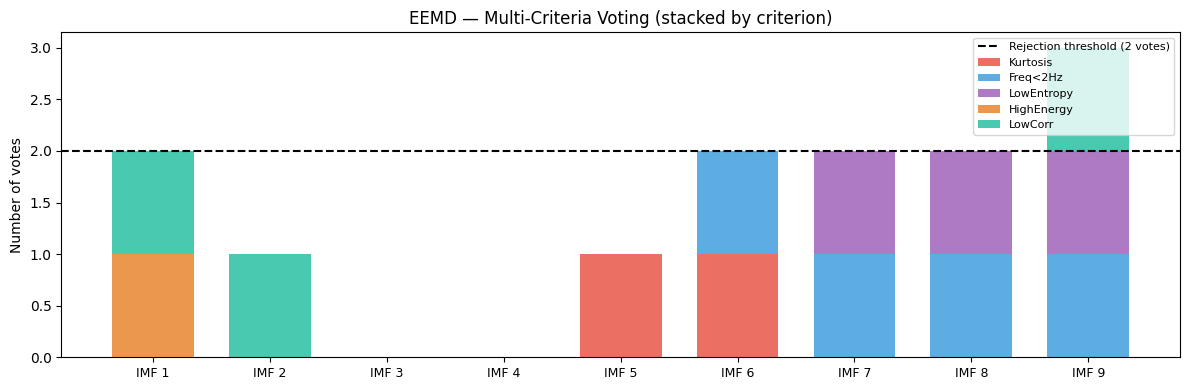

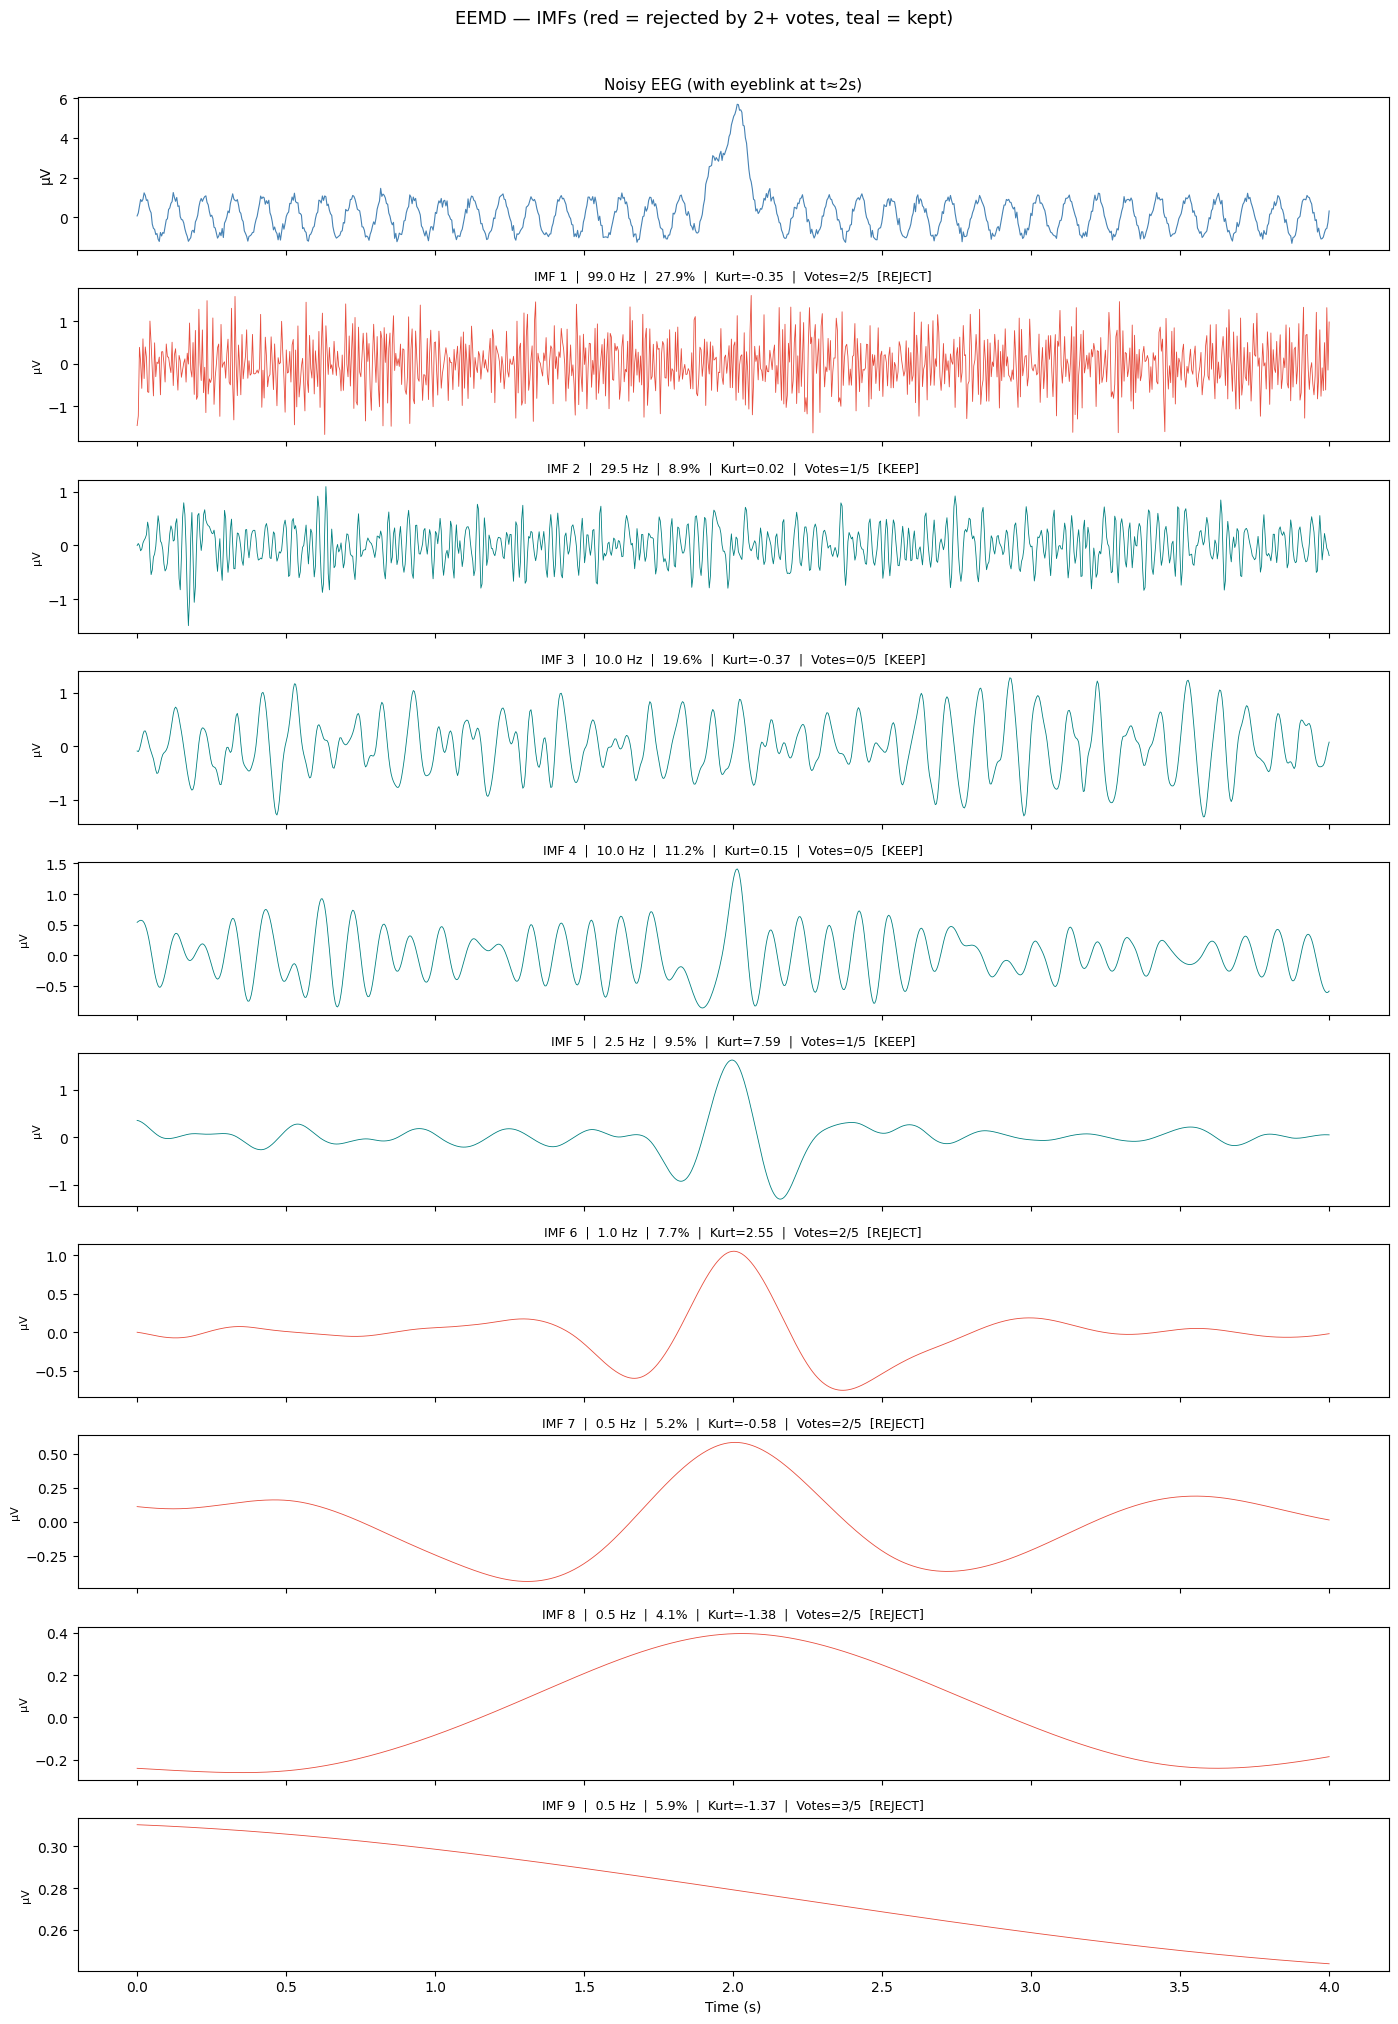

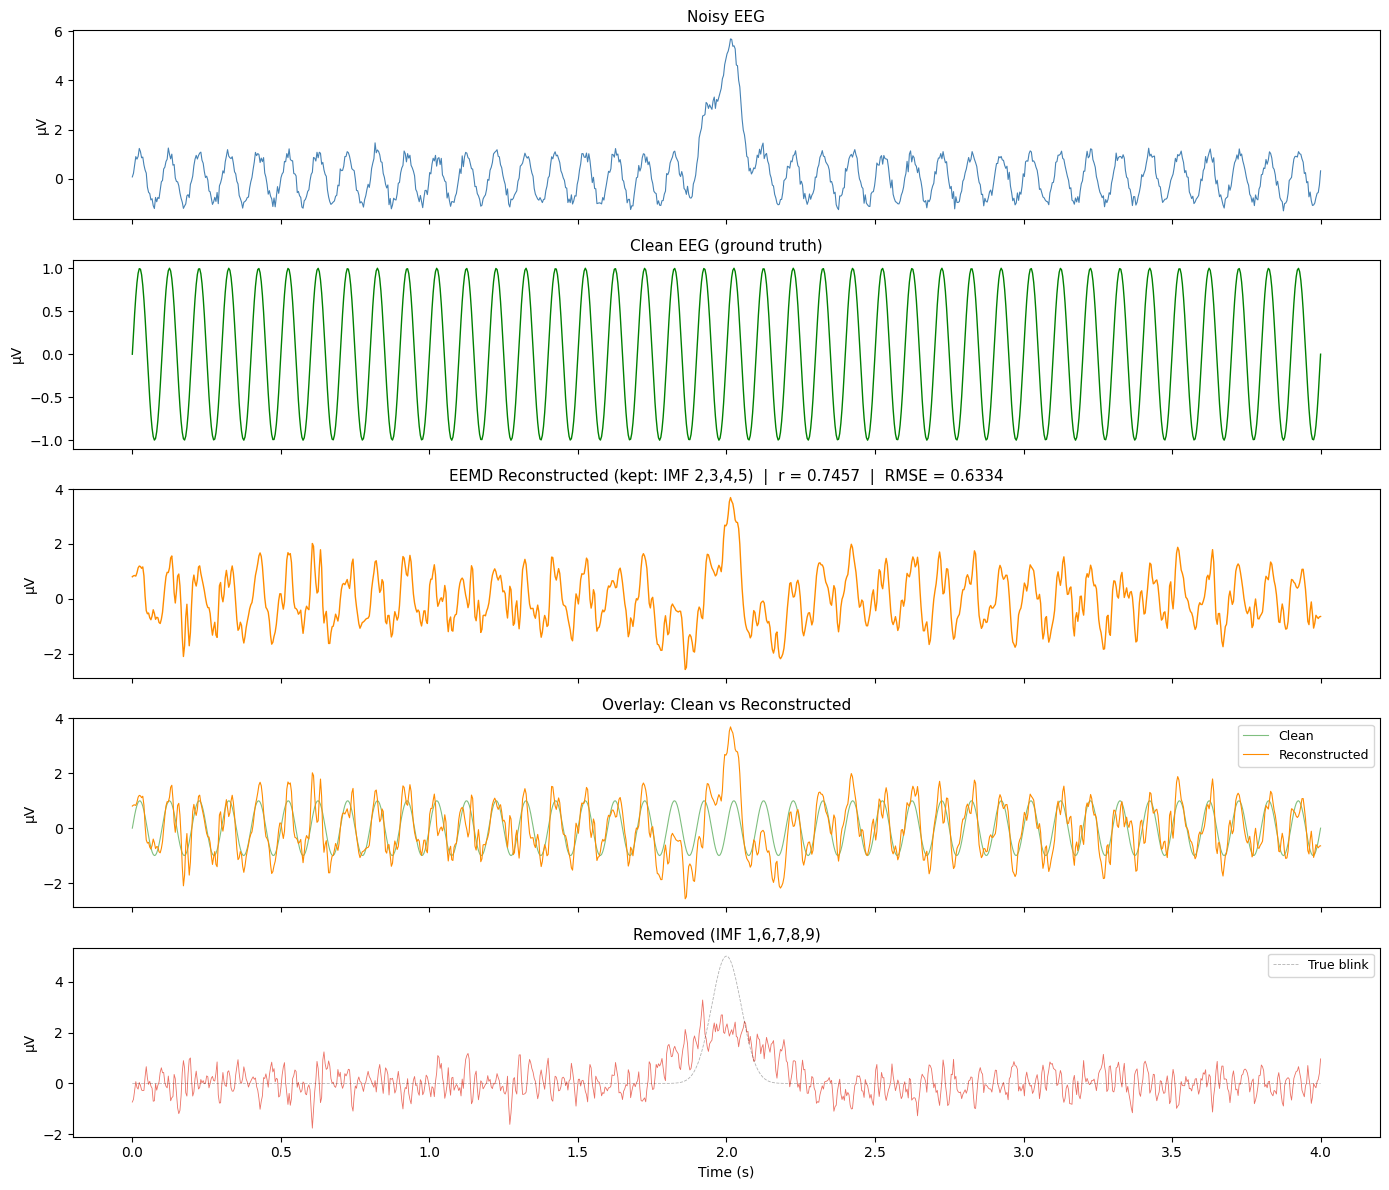

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EEMD
from scipy.stats import kurtosis, pearsonr
from scipy.signal import welch
import pandas as pd

# ═══════════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════════
def sample_entropy(x, m=2, r_frac=0.2):
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = r_frac * np.std(x)
    if r == 0 or N < m + 2:
        return 0.0
    def _count(tl):
        templates = np.lib.stride_tricks.sliding_window_view(x, tl)
        count = 0
        for i in range(len(templates)):
            dists = np.max(np.abs(templates[i] - templates), axis=1)
            count += np.sum(dists < r) - 1
        return count
    A, B = _count(m + 1), _count(m)
    if B == 0 or A == 0:
        return 0.0
    return -np.log(A / B)

# ═══════════════════════════════════════════════════════════════════════
# 1. CREATE THE SIGNAL
# ═══════════════════════════════════════════════════════════════════════
np.random.seed(42)
fs = 256
t = np.linspace(0, 4, fs * 4)

# Clean EEG: just a single 10 Hz alpha rhythm
clean_eeg = 1.0 * np.sin(2 * np.pi * 10 * t)

# Eyeblink artifact: big, slow Gaussian bump
blink = 5 * np.exp(-((t - 2.0) ** 2) / (2 * 0.05**2))

# Noisy signal
noisy_eeg = clean_eeg + blink + 0.15 * np.random.randn(len(t))


# ═══════════════════════════════════════════════════════════════════════
# 2. APPLY EEMD
# ═══════════════════════════════════════════════════════════════════════
eemd = EEMD(trials=100, noise_width=0.2)
imfs = eemd.eemd(noisy_eeg, t)
n_imfs = imfs.shape[0]

# ═══════════════════════════════════════════════════════════════════════
# 3. COMPUTE ALL METRICS
# ═══════════════════════════════════════════════════════════════════════
entropies = np.array([sample_entropy(imf[:300]) for imf in imfs])
kurts_arr = np.array([kurtosis(imf) for imf in imfs])

dom_freqs = []
for imf in imfs:
    f, psd = welch(imf, fs=fs, nperseg=min(512, len(imf)))
    dom_freqs.append(f[np.argmax(psd)])
dom_freqs = np.array(dom_freqs)

energies = np.array([np.sum(imf**2) for imf in imfs])
energy_pct = energies / energies.sum() * 100

corrs = np.array([abs(pearsonr(imf, noisy_eeg)[0]) for imf in imfs])

# ═══════════════════════════════════════════════════════════════════════
# 4. MULTI-CRITERIA REJECTION (vote-based)
# ═══════════════════════════════════════════════════════════════════════
# Criterion 1: Kurtosis — high |kurtosis| = peaky transient (blink)
m_kurt = np.abs(kurts_arr) > 2.0

# Criterion 2: Dominant frequency < 2 Hz = drift / blink residual
m_freq = dom_freqs < 2.0

# Criterion 3: Very low entropy = too regular / residual trend
m_entropy = entropies < 0.05

# Criterion 4: Energy outlier = abnormally dominant component
m_energy = energy_pct > (np.mean(energy_pct) + 2 * np.std(energy_pct))

# Criterion 5: Low correlation with original = not contributing to signal
m_corr = corrs < np.median(corrs) * 0.3

# Vote: reject if 2+ criteria agree
votes = (m_kurt.astype(int) + m_freq.astype(int) + m_entropy.astype(int)
         + m_energy.astype(int) + m_corr.astype(int))
vote_threshold = 2
reject_mask = votes >= vote_threshold
keep_mask = ~reject_mask

# ═══════════════════════════════════════════════════════════════════════
# 5. DIAGNOSTICS TABLE
# ═══════════════════════════════════════════════════════════════════════
print("EEMD Multi-Criteria Rejection")
print("=" * 95)
print(f"{'IMF':<6} {'DomHz':>7} {'E%':>7} {'SampEn':>8} {'Kurt':>8} {'|r|':>7} | "
      f"{'Kurt':>5} {'Freq':>5} {'Entr':>5} {'Ener':>5} {'Corr':>5} | {'Votes':>5} {'Decision':<8}")
print("-" * 95)

for i in range(n_imfs):
    flags = [m_kurt[i], m_freq[i], m_entropy[i], m_energy[i], m_corr[i]]
    flag_strs = ["  ##" if f else "   ." for f in flags]
    decision = "REJECT" if reject_mask[i] else "KEEP"
    print(f"IMF {i+1:<2} {dom_freqs[i]:7.1f} {energy_pct[i]:6.1f}% {entropies[i]:8.4f} "
          f"{kurts_arr[i]:8.4f} {corrs[i]:7.4f} | "
          f"{''.join(flag_strs)} | {votes[i]:>5} {decision:<8}")

reconstructed = np.sum(imfs[keep_mask], axis=0)
r_val, _ = pearsonr(clean_eeg, reconstructed)
rmse = np.sqrt(np.mean((clean_eeg - reconstructed)**2))

removed_ids = ",".join(str(i+1) for i in range(n_imfs) if reject_mask[i])
kept_ids = ",".join(str(i+1) for i in range(n_imfs) if keep_mask[i])
print(f"\nRemoved: IMF {removed_ids if removed_ids else 'none'}")
print(f"Kept:    IMF {kept_ids}")
print(f"Pearson r = {r_val:.4f}  |  RMSE = {rmse:.4f}")

# ═══════════════════════════════════════════════════════════════════════
# 6. PLOT: Criteria bar chart (why each IMF was rejected)
# ═══════════════════════════════════════════════════════════════════════
criteria_names = ['Kurtosis', 'Freq<2Hz', 'LowEntropy', 'HighEnergy', 'LowCorr']
criteria_masks = [m_kurt, m_freq, m_entropy, m_energy, m_corr]
criteria_colors = ['#e74c3c', '#3498db', '#9b59b6', '#e67e22', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(n_imfs)
bottom = np.zeros(n_imfs)
for cname, cmask, ccolor in zip(criteria_names, criteria_masks, criteria_colors):
    vals = cmask.astype(float)
    ax.bar(x, vals, bottom=bottom, color=ccolor, label=cname, alpha=0.8, width=0.7)
    bottom += vals

ax.axhline(vote_threshold, color='black', ls='--', lw=1.5, label=f'Rejection threshold ({vote_threshold} votes)')
ax.set_xticks(x)
ax.set_xticklabels([f'IMF {i+1}' for i in range(n_imfs)], fontsize=9)
ax.set_ylabel('Number of votes')
ax.set_title('EEMD — Multi-Criteria Voting (stacked by criterion)', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# 7. PLOT IMFs (color-coded keep/reject)
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 2 * (n_imfs + 1)), sharex=True)

axes[0].plot(t, noisy_eeg, color="steelblue", lw=0.8)
axes[0].set_title("Noisy EEG (with eyeblink at t≈2s)", fontsize=11)
axes[0].set_ylabel("µV")

for i in range(n_imfs):
    is_art = reject_mask[i]
    color = "#e74c3c" if is_art else "teal"
    tag = "REJECT" if is_art else "KEEP"
    axes[i+1].plot(t, imfs[i], color=color, lw=0.6)
    axes[i+1].set_title(
        f"IMF {i+1}  |  {dom_freqs[i]:.1f} Hz  |  {energy_pct[i]:.1f}%  |  "
        f"Kurt={kurts_arr[i]:.2f}  |  Votes={votes[i]}/5  [{tag}]", fontsize=9)
    axes[i+1].set_ylabel("µV", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EEMD — IMFs (red = rejected by 2+ votes, teal = kept)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# 8. PLOT: Original vs Clean vs Reconstructed
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, noisy_eeg, color="steelblue", lw=0.8)
axes[0].set_title("Noisy EEG", fontsize=11)
axes[0].set_ylabel("µV")

axes[1].plot(t, clean_eeg, color="green", lw=1)
axes[1].set_title("Clean EEG (ground truth)", fontsize=11)
axes[1].set_ylabel("µV")

axes[2].plot(t, reconstructed, color="darkorange", lw=1)
axes[2].set_title(
    f"EEMD Reconstructed (kept: IMF {kept_ids})  |  "
    f"r = {r_val:.4f}  |  RMSE = {rmse:.4f}", fontsize=11)
axes[2].set_ylabel("µV")

axes[3].plot(t, clean_eeg, color="green", lw=0.8, alpha=0.5, label="Clean")
axes[3].plot(t, reconstructed, color="darkorange", lw=0.8, label="Reconstructed")
axes[3].set_title("Overlay: Clean vs Reconstructed", fontsize=11)
axes[3].set_ylabel("µV")
axes[3].legend(fontsize=9)

removed = noisy_eeg - reconstructed
axes[4].plot(t, removed, color="#e74c3c", lw=0.6, alpha=0.8)
axes[4].plot(t, blink, color="black", lw=0.6, alpha=0.3, ls="--", label="True blink")
axes[4].set_title(f"Removed (IMF {removed_ids})", fontsize=11)
axes[4].set_ylabel("µV")
axes[4].set_xlabel("Time (s)")
axes[4].legend(fontsize=9)

plt.tight_layout()
plt.show()


CEEMDAN Decomposition Metrics
  IMF Dom Freq (Hz) Energy % Sample Entropy Kurtosis
IMF 1          98.0      3.1         1.7403  -0.4766
IMF 2          45.5      0.7         1.5783  -0.3227
IMF 3          10.0     56.5         0.4471  -0.7634
IMF 4           4.0      9.6         0.4075  10.9399
IMF 5           2.5      6.4         0.2191   4.7016
IMF 6           1.5     10.4         0.0201   0.5209
IMF 7           0.5      7.6         0.0069  -0.1651
IMF 8           0.5      5.8         0.0054  -1.3005

Kurtosis threshold: 3.0
  IMF 1: kurtosis=-0.4766  → KEEP
  IMF 2: kurtosis=-0.3227  → KEEP
  IMF 3: kurtosis=-0.7634  → KEEP
  IMF 4: kurtosis=10.9399  → REJECT
  IMF 5: kurtosis=4.7016  → REJECT
  IMF 6: kurtosis=0.5209  → KEEP
  IMF 7: kurtosis=-0.1651  → KEEP
  IMF 8: kurtosis=-1.3005  → KEEP

Pearson r = 0.7972  |  RMSE = 0.4463


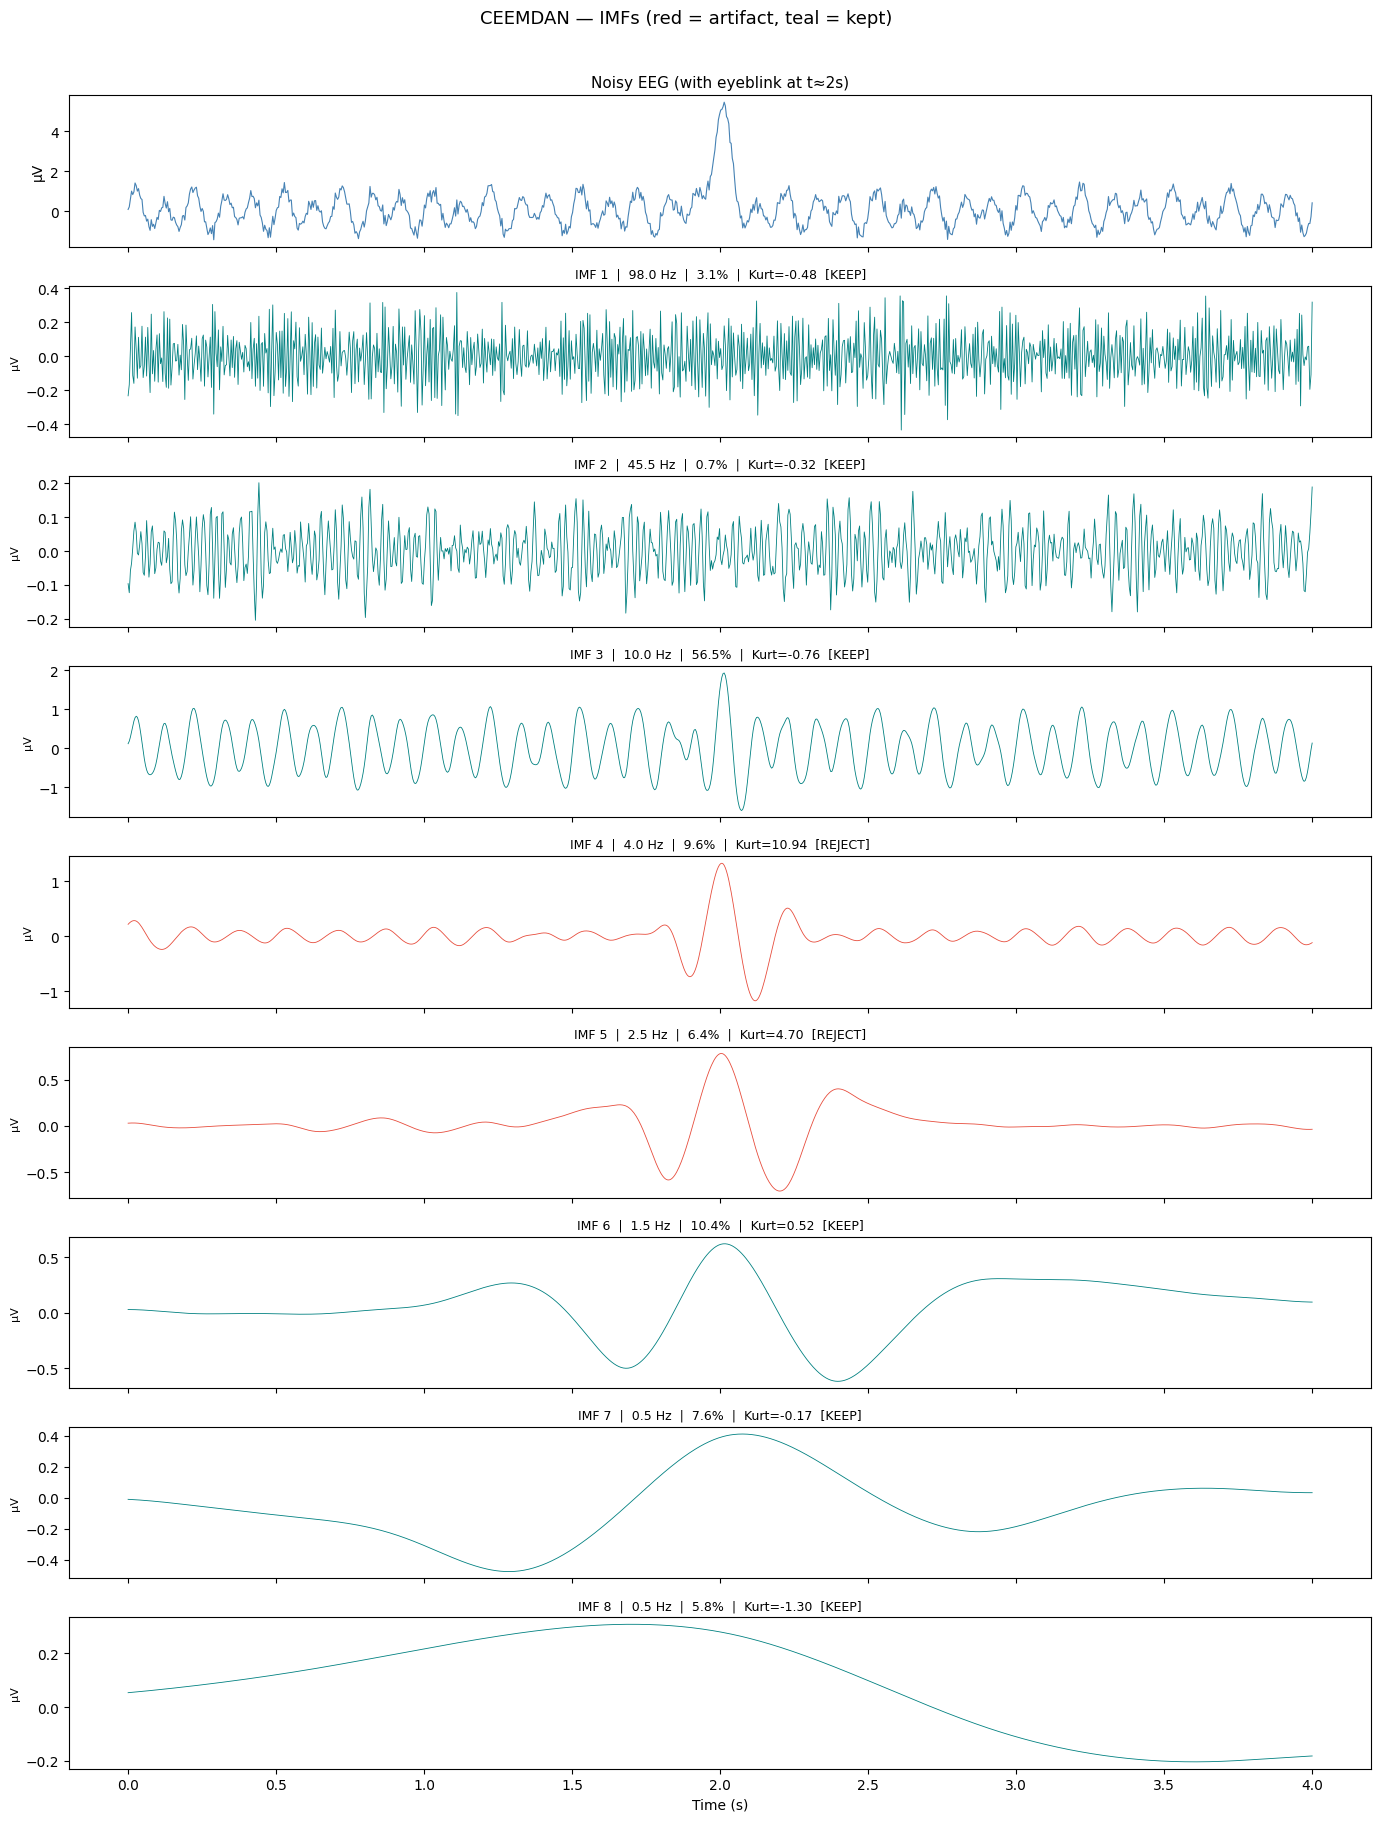

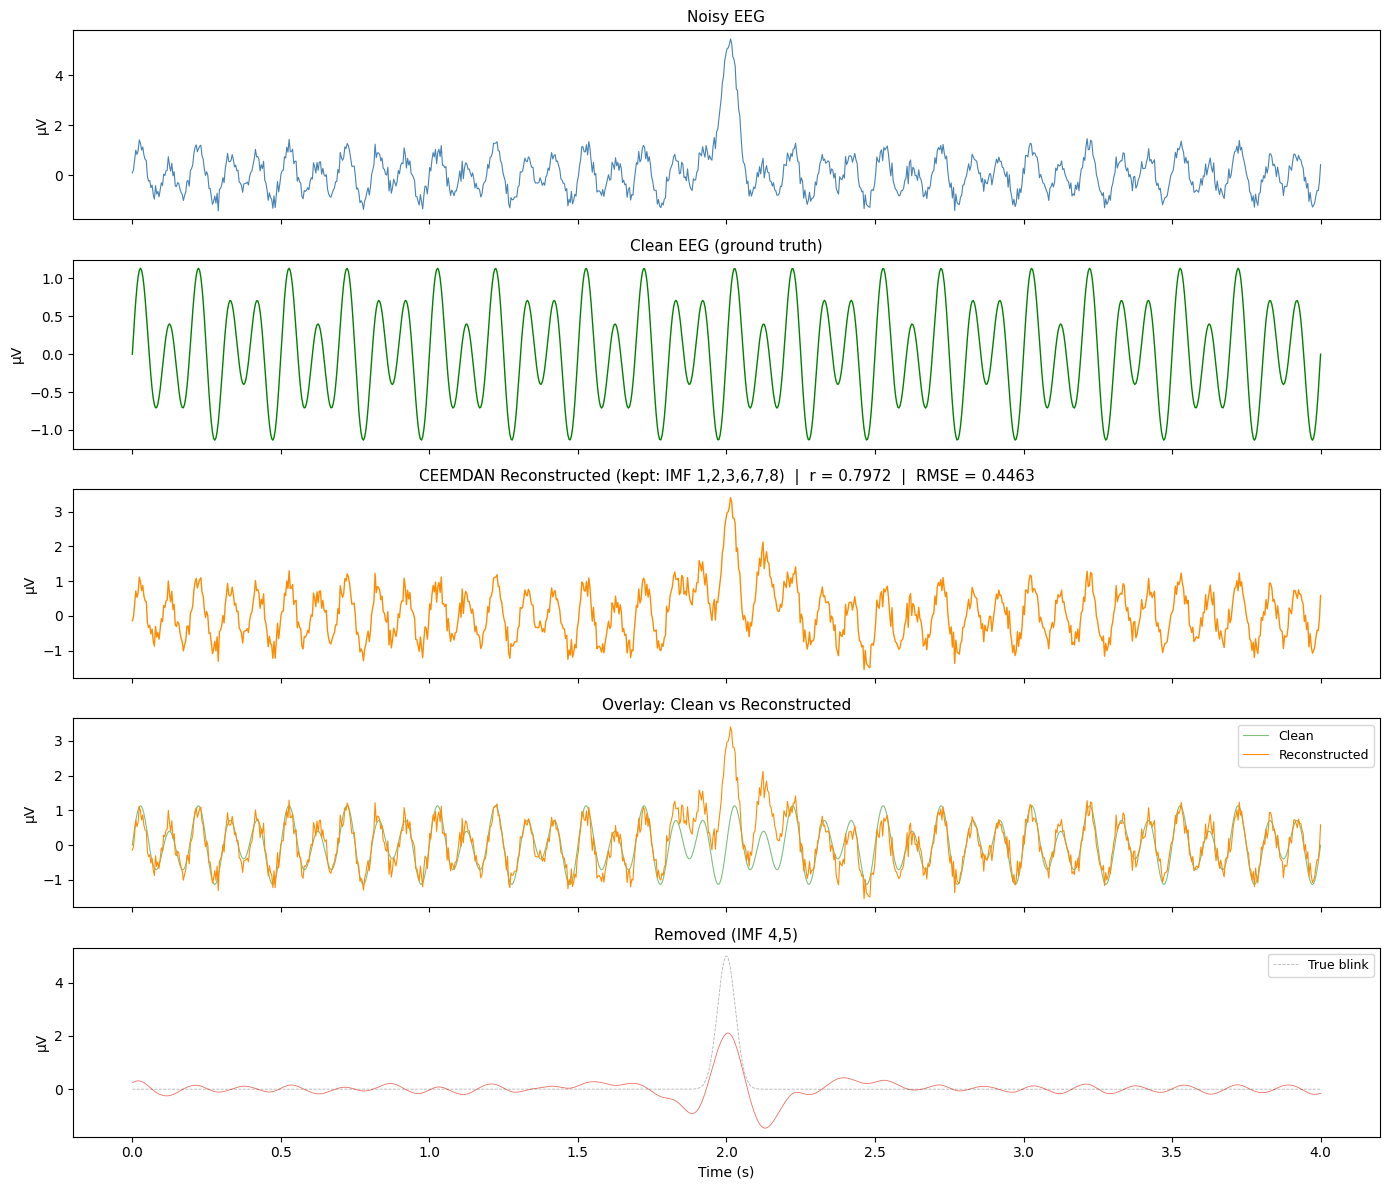


Method        Pearson r       RMSE Removed IMFs        
EEMD             0.5829     0.9218 IMF 
CEEMDAN          0.7972     0.4463 IMF 4,5


In [12]:
from PyEMD import CEEMDAN

# ═══════════════════════════════════════════════════════════════════════
# CEEMDAN DECOMPOSITION (same signal)
# ═══════════════════════════════════════════════════════════════════════
ceemdan = CEEMDAN(trials=100, epsilon=0.2)
imfs_c = ceemdan.ceemdan(noisy_eeg, t)
n_imfs_c = imfs_c.shape[0]

# ═══════════════════════════════════════════════════════════════════════
# METRICS TABLE
# ═══════════════════════════════════════════════════════════════════════
entropies_c = [sample_entropy(imf[:300]) for imf in imfs_c]
kurts_c = np.array([kurtosis(imf) for imf in imfs_c])

dom_freqs_c = []
for imf in imfs_c:
    f, psd = welch(imf, fs=fs, nperseg=min(512, len(imf)))
    dom_freqs_c.append(f[np.argmax(psd)])

energies_c = np.array([np.sum(imf**2) for imf in imfs_c])
energy_pct_c = energies_c / energies_c.sum() * 100

df_c = pd.DataFrame({
    "IMF": [f"IMF {i+1}" for i in range(n_imfs_c)],
    "Dom Freq (Hz)": [f"{d:.1f}" for d in dom_freqs_c],
    "Energy %": [f"{e:.1f}" for e in energy_pct_c],
    "Sample Entropy": [f"{e:.4f}" for e in entropies_c],
    "Kurtosis": [f"{k:.4f}" for k in kurts_c],
})
print("CEEMDAN Decomposition Metrics")
print("=" * 65)
print(df_c.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════
# KURTOSIS THRESHOLD → REJECT
# ═══════════════════════════════════════════════════════════════════════
keep_mask_c = np.abs(kurts_c) < kurt_threshold

print(f"\nKurtosis threshold: {kurt_threshold}")
for i in range(n_imfs_c):
    tag = "KEEP" if keep_mask_c[i] else "REJECT"
    print(f"  IMF {i+1}: kurtosis={kurts_c[i]:.4f}  → {tag}")

reconstructed_c = np.sum(imfs_c[keep_mask_c], axis=0)
r_val_c, _ = pearsonr(clean_eeg, reconstructed_c)
rmse_c = np.sqrt(np.mean((clean_eeg - reconstructed_c)**2))
print(f"\nPearson r = {r_val_c:.4f}  |  RMSE = {rmse_c:.4f}")

# ═══════════════════════════════════════════════════════════════════════
# PLOT 1: IMFs (color-coded keep/reject)
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(n_imfs_c + 1, 1, figsize=(14, 2 * (n_imfs_c + 1)), sharex=True)

axes[0].plot(t, noisy_eeg, color="steelblue", lw=0.8)
axes[0].set_title("Noisy EEG (with eyeblink at t≈2s)", fontsize=11)
axes[0].set_ylabel("µV")

for i in range(n_imfs_c):
    is_artifact = not keep_mask_c[i]
    color = "#e74c3c" if is_artifact else "teal"
    tag = "REJECT" if is_artifact else "KEEP"
    axes[i+1].plot(t, imfs_c[i], color=color, lw=0.6)
    axes[i+1].set_title(
        f"IMF {i+1}  |  {dom_freqs_c[i]:.1f} Hz  |  {energy_pct_c[i]:.1f}%  |  "
        f"Kurt={kurts_c[i]:.2f}  [{tag}]", fontsize=9)
    axes[i+1].set_ylabel("µV", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("CEEMDAN — IMFs (red = artifact, teal = kept)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT 2: Original vs Clean vs Reconstructed
# ═══════════════════════════════════════════════════════════════════════
kept_ids_c = ",".join(str(i+1) for i in range(n_imfs_c) if keep_mask_c[i])
removed_ids_c = ",".join(str(i+1) for i in range(n_imfs_c) if not keep_mask_c[i])

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, noisy_eeg, color="steelblue", lw=0.8)
axes[0].set_title("Noisy EEG", fontsize=11)
axes[0].set_ylabel("µV")

axes[1].plot(t, clean_eeg, color="green", lw=1)
axes[1].set_title("Clean EEG (ground truth)", fontsize=11)
axes[1].set_ylabel("µV")

axes[2].plot(t, reconstructed_c, color="darkorange", lw=1)
axes[2].set_title(
    f"CEEMDAN Reconstructed (kept: IMF {kept_ids_c})  |  "
    f"r = {r_val_c:.4f}  |  RMSE = {rmse_c:.4f}", fontsize=11)
axes[2].set_ylabel("µV")

axes[3].plot(t, clean_eeg, color="green", lw=0.8, alpha=0.5, label="Clean")
axes[3].plot(t, reconstructed_c, color="darkorange", lw=0.8, label="Reconstructed")
axes[3].set_title("Overlay: Clean vs Reconstructed", fontsize=11)
axes[3].set_ylabel("µV")
axes[3].legend(fontsize=9)

removed_c = noisy_eeg - reconstructed_c
axes[4].plot(t, removed_c, color="#e74c3c", lw=0.6, alpha=0.8)
axes[4].plot(t, blink, color="black", lw=0.6, alpha=0.3, ls="--", label="True blink")
axes[4].set_title(f"Removed (IMF {removed_ids_c})", fontsize=11)
axes[4].set_ylabel("µV")
axes[4].set_xlabel("Time (s)")
axes[4].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# COMPARISON: EEMD vs CEEMDAN
# ═══════════════════════════════════════════════════════════════════════
print(f"\n{'Method':<12} {'Pearson r':>10} {'RMSE':>10} {'Removed IMFs':<20}")
print("=" * 55)
print(f"{'EEMD':<12} {r_val:>10.4f} {rmse:>10.4f} IMF {removed_ids}")
print(f"{'CEEMDAN':<12} {r_val_c:>10.4f} {rmse_c:>10.4f} IMF {removed_ids_c}")


### 7. Evaluation and Choice of Parameters
These methods (WT, EMD, ICA) are often paired and then evaluated using **Entropy Thresholds** to determine which components are noise and which are signal.

---
**Bottom Line:** Whether using Wavelets or the EMD family (EEMD, CEEMDAN), these techniques can all be cross-paired with ICA to create a robust, multi-stage cleaning pipeline for EEG.

---
### References
*   [EEG Artifacts Handling in Analyzer — Brain Products](https://pressrelease.brainproducts.com/eeg-artifacts-handling-in-analyzer/)